# BÁO CÁO PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA) HÀNH VI TƯƠNG TÁC AGENT TRÊN FACEBOOK
## ĐỐI SÁNH NHÓM CAN THIỆP PERSONA (INTERVENTION) VS NHÓM ĐỐI CHỨNG TRUNG TÍNH (NEUTRAL CONTROL)

---

### Pipeline EDA: Tuân thủ quy chuẩn `notebooks/pipeline_eda.md`
- **Dữ liệu phân tích:** `data/action_logs/benchmark_eda_*.json` (Nhóm Persona) & `data/no_persona_Action/benchmark_eda_*.json` (Nhóm No-Persona/Neutral).
- **Đơn vị phân tích:** 
  1. Cấp độ Phiên chạy (`Episode level`): $N = 8$ phiên duyệt Facebook mô phỏng.
  2. Cấp độ Bước hành động (`Step level`): $N = 437$ bước hành vi tuần tự (349 Persona vs 88 Neutral Control).
  3. Cấp độ Thao tác vật lý (`Recent Actions / Browser Gestures`): $N = 189$ hành vi trình duyệt duy nhất (63 thao tác cuộn chuột).
  4. Cấp độ Mạch nhận thức (`Active Threads / Cognitive Evidence`): $N = 2,441$ trạng thái mạch chủ đề & 546 bằng chứng tâm lý.

# BƯỚC 1: XÁC ĐỊNH MỤC TIÊU VÀ CÂU HỎI NGHIÊN CỨU (RESEARCH QUESTIONS & HYPOTHESES)

## 1.1. Mục tiêu tổng quát & Đối tượng độc giả
- **Mục tiêu cốt lõi:** Đánh giá tính chân thực (Persona Fidelity), tính nhất quán nhận thức (Cognitive Consistency), và khả năng tự kiểm soát hành vi (Self-Regulation & Spatial Navigation) của mô hình ngôn ngữ lớn (LLM) khi được nạp hồ sơ người dùng (Persona) duyệt mạng xã hội Facebook, đặt trong mối tương quan đối sánh với nhóm đối chứng không có Persona (Neutral Control).
- **Đối tượng độc giả:** Thành viên trong nhóm tìm hiểu persona agent trong môi trường mạng xã hội. Tiêu chuẩn đánh giá: Kiểm định thống kê, đo lường Effect Size.

## 1.2. Danh sách 5 Câu hỏi Nghiên cứu Cụ thể (Research Questions - RQ)

| Mã RQ | Tên Câu hỏi Nghiên cứu | Mục tiêu trả lời của EDA |
| :--- | :--- | :--- |
| **RQ1** | **Tính Điều hướng của Persona (Persona Steering & Content Selection)** | *Việc nạp hồ sơ Persona có thực sự điều hướng được không gian hành động (`intent`, `tool`) và đối tượng mục tiêu (`target_candidate`: post, group, page) của Agent so với nhóm đối chứng trung tính hay không?* |
| **RQ2** | **Tính Nhất quán Cơ học - Vật lý (Biomechanical & Physical Pacing)** | *Hồ sơ tâm lý trừu tượng (`pace: quick/slow`, `readingDepth: skim/selective`) có được chuyển hóa nhất quán thành các thông số cử chỉ cuộn chuột vật lý trên trình duyệt (`gesture_ms`, `gesture_total_px`, `gesture_pace`) hay không?* |
| **RQ3** | **Khả năng Kháng Nhiễu & Trôi dạt Nhận thức (Cognitive Drift & Distraction)** | *Khi tiếp xúc với các nội dung hấp dẫn ngẫu nhiên trên feed, nhóm Persona có khả năng duy trì tập trung vào chủ đề cốt lõi tốt hơn nhóm No-Persona không? (Đo lường qua `situational_steps`, `explored_evidence_share` và tần suất kích hoạt `CẢNH BÁO TIẾT CHẾ`).* |
| **RQ4** | **Hành trình Không gian & Vận tốc Tương tác (Spatial Journey & Velocity)** | *Sự hiện diện của Persona tác động thế nào đến hành trình chuyển dịch bề mặt (`Surface Transitions`: Feed $\leftrightarrow$ Search $\leftrightarrow$ Group $\leftrightarrow$ Page) và vận tốc thao tác (`Action Velocity`: actions/phút) của Agent?* |
| **RQ5** | **Ký ức Đa phiên & Quản trị Ngân sách Thời gian (Longitudinal Memory & Time Budget)** | *Agent có thể hiện cơ chế ký ức sở thích đa phiên (`Cross-session Memory Queries`) để chống lặp truy vấn và có tự động điều tiết hành vi kết thúc phiên theo ngân sách thời gian (`planned_session_minutes`) hay không?* |

## 1.3. Danh sách Giả thuyết Kỳ vọng Trước Thực nghiệm (Prior Hypotheses: $H_1 \rightarrow H_5$)

Việc xác lập giả thuyết trước khi đi sâu vào dữ liệu giúp ngăn ngừa hiện tượng **Confirmation Bias (Thiên lệch xác nhận)**:

1. **Giả thuyết $H_1$ (Lựa chọn nội dung mục tiêu - Target Selection Fidelity):**
   - *Kỳ vọng:* Nhóm Persona sẽ có tỷ lệ nhắm trúng các thực thể nội dung (`target_candidate`) khớp với sở thích cốt lõi (Thiền, Cờ vua, Thể hình, Triết học) đạt trên **85%**, với trọng số quyết định (`dimension_evidence.weight`) trung bình $> 0.70$. Ngược lại, nhóm No-Persona sẽ phân bổ hành vi tương tác phân tán hoặc thụ động theo thứ tự xuất hiện trên viewport.

2. **Giả thuyết $H_2$ (Nhất quán cơ học cuộn chuột - Biomechanical Consistency):**
   - *Kỳ vọng:* Tồn tại sự phân hóa đơn điệu rõ rệt giữa nhãn tốc độ trong hồ sơ Persona và thông số đo đạc vật lý trên trình duyệt:
     - Persona `pace = quick`: 100% cử chỉ cuộn đạt `gesture_pace = fast`, thời gian cử chỉ $t < 200\text{ ms}$, quãng đường cuộn trung bình $d > 800\text{ px}$.
     - Persona `pace = slow/balanced`: 100% cử chỉ cuộn đạt `gesture_pace = careful`, thời gian cử chỉ $t > 240\text{ ms}$, quãng đường cuộn $d < 500\text{ px}$.
     - Nhóm No-Persona: Bị rơi vào trạng thái mặc định của crawler (`careful`), nhưng quãng cuộn không được điều tiết theo `readingDepth`.

3. **Giả thuyết $H_3$ (Kháng trôi dạt nhận thức - Cognitive Anti-Drift):**
   - *Kỳ vọng:* Nhóm Persona có `situational_steps = 0` và hoàn toàn không phát sinh cảnh báo tiết chế trong suốt phiên chạy. Nhóm No-Persona sẽ xuất hiện hiện tượng trôi dạt nhận thức (sa đà vào chủ đề tình huống $\ge 5$ bước liên tiếp) và kích hoạt ít nhất 10 lần dòng thông điệp `CẢNH BÁO TIẾT CHẾ`.

4. **Giả thuyết $H_4$ (Đa dạng không gian & Vận tốc thao tác - Spatial Diversity & Velocity):**
   - *Kỳ vọng:* Nhóm Persona có mục đích rõ ràng nên sẽ ghé thăm nhiều bề mặt hơn (trung bình $\ge 3.5$ bề mặt: Feed, Search, Group, Page) và đạt vận tốc thao tác cao hơn ít nhất gấp 2 lần ($> 2.5\text{ actions/phút}$) so với nhóm No-Persona ($< 1.0\text{ action/phút}$, chủ yếu bị kẹt ở Newsfeed).

5. **Giả thuyết $H_5$ (Ký ức đa phiên & Nhận thức thời gian - Cross-session Memory & Budget):**
   - *Kỳ vọng:* Agent nhóm Persona có khả năng nạp và duy trì truy vấn từ bộ nhớ phiên trước (`recent_queries_from_memory`) xuyên suốt ít nhất 20 bước, đồng thời tỷ lệ hoàn thành hành động đạt điểm hội tụ khi `remaining_seconds` tiến gần về 0.

## 1.4. Khung Ma trận Chỉ số Định lượng (Quantitative Metrics Framework)

| Câu hỏi | Biến Độc lập (Ngữ cảnh $S_t$) | Biến Phụ thuộc (Hành vi $A_t$) | Thước đo Thống kê / Kiểm định (Algorithm) | File Thuật toán phụ trách (`algorithms/`) |
| :--- | :--- | :--- | :--- | :--- |
| **RQ1** | `dataset_type`, `persona_id`, `interests` | `intent`, `target_candidate.kind`, `dim_evidence` | Chi-square Independence, Cramér's V, Delta-P Lift | `algorithms/fast_chi2_independence.py`, `algorithms/delta_p_lift.py` |
| **RQ2** | `persona_pace`, `persona_reading_depth` | `gesture_pace`, `gesture_ms`, `gesture_total_px` | Mann-Whitney U test, Cohen's d, Spearman rank correlation | `algorithms/pace_gesture_correlation.py` (Tạo mới) |
| **RQ3** | `dataset_type`, `novelty.guidance` | `wm_situational_steps`, `has_novelty_warning` | Cochran-Armitage Trend Test, Wilson Score Interval | `algorithms/cochran_armitage_trend.py`, `algorithms/wilson_score_interval.py` |
| **RQ4** | `dataset_type`, `surface_journey` | `action_velocity_per_min`, `surfaces_visited_count` | Transition Entropy, Two-sample t-test, Permutation test | `algorithms/surface_transition_matrix.py` (Tạo mới) |
| **RQ5** | `planned_session_minutes`, `elapsed_seconds` | `has_memory_queries`, `is_overtime`, `terminal_reason` | Jensen-Shannon Divergence, Survival/Completion curve | `algorithms/jensen_shannon_divergence.py` |

---
**KẾT THÚC BƯỚC 1.** Đầu ra của Bước 1 đã xác lập đầy đủ hệ thống 5 câu hỏi và 5 giả thuyết kỳ vọng. Chúng ta sẽ tiến hành cấu hình môi trường và chuyển tiếp sang **Bước 2: Hiểu bối cảnh và nguồn gốc dữ liệu**.

In [1]:
# Khởi tạo môi trường, import các thư viện cốt lõi và nạp Loader
import sys
from pathlib import Path

# Đảm bảo project root và thư mục algorithms, viz có trong sys.path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị pandas
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Import PersonaActionLoader chuẩn từ loaders
from loaders.loaders.persona_action import PersonaActionLoader

loader = PersonaActionLoader()
print("[✓] Đã khởi tạo PersonaActionLoader thành công!")
print(f"[✓] Thư mục gốc project: {project_root}")
print(f"[✓] Thư mục lưu bảng (CSV): {project_root / 'output' / 'tables'}")
print(f"[✓] Thư mục lưu biểu đồ (PNG): {project_root / 'output' / 'figures'}")

[✓] Đã khởi tạo PersonaActionLoader thành công!
[✓] Thư mục gốc project: D:\source_code\eda_persona
[✓] Thư mục lưu bảng (CSV): D:\source_code\eda_persona\output\tables
[✓] Thư mục lưu biểu đồ (PNG): D:\source_code\eda_persona\output\figures


# BƯỚC 2: HIỂU BỐI CẢNH VÀ NGUỒN GỐC DỮ LIỆU (DATA PROVENANCE & LINEAGE)

## 2.1. Bối cảnh Sinh Dữ liệu & Thiết kế Thực nghiệm (Experiment Setup)

- **Tác nhân sinh dữ liệu (Generation Engine):**
  - Dữ liệu được sinh ra từ các **Tác tử Trí tuệ Nhân tạo Tự trị (Autonomous AI Agents)** xây dựng trên nền tảng **DeepSeek Harness** (mô hình GLM 5.3 Flash).
  - Tác tử điều khiển trình duyệt qua Playwright, kết nối Chromium bằng CDP. Tích hợp lớp cloak/stealth để giảm dấu hiệu automation. Lớp hành vi mô phỏng người dùng: smooth_wheel cuộn theo gia tốc với delta/delay ngẫu nhiên; native_click chọn tọa độ ngẫu nhiên trong vùng hiển thị hợp lệ của phần tử, dùng CDP Input.dispatchMouseEvent và mô phỏng hover/mouse move.

- **Môi trường & Đặc tính Tài khoản (Cold-Start / Fresh Facebook Accounts):**
  - Tác tử thao tác trực tiếp trên giao diện web desktop của Facebook (`https://www.facebook.com`).
  - Toàn bộ các phiên chạy được thực hiện trên **tài khoản Facebook mới tạo hoàn toàn (Tài khoản trắng - Cold start)**: không có bạn bè, không có lịch sử like/share, không follow trang/nhóm nào trước đó.
  - **Ý nghĩa cốt lõi:** Việc sử dụng tài khoản trắng loại bỏ hoàn toàn **Thiên lệch Thuật toán Đề xuất của Meta**. Bảng tin ban đầu là trung tính tuyệt đối; mọi sự phân hóa trong hành vi duyệt bài, từ khóa tìm kiếm hay nội dung tương tác đều phản ánh thuần túy sự điều hướng của hồ sơ Persona (hoặc tính ngẫu nhiên của nhóm đối chứng).

- **Khoảng thời gian thu thập & Quy mô:**
  - Dữ liệu thu thập ngày **30/09/2026**.
  - Thiết kế A/B đối sánh: **6 phiên can thiệp có Persona** đối sánh với **2 phiên đối chứng không có Persona (Neutral Control)**.

## 2.2. Chu trình Hoạt động của Agent (Agent Loop Lifecycle & Data Generation)

Toàn bộ dữ liệu dùng cho phân tích EDA được sinh ra từ chu trình vòng lặp tác tử tự trị (**Agent Loop**) qua 3 tầng kiến trúc cốt lõi:

![Kiến trúc Chu trình Vòng lặp Agent](output/figures/agent_loop.png)

### Ba Tầng Hoạt động trong Chu trình Sinh Dữ liệu:

1. **Tầng Quản lý & Khởi tạo Môi trường (Management Layer):**
   - **Đầu vào:** Ghép cặp hồ sơ người dùng (`Persona`) với tài khoản Facebook trắng hoàn toàn (`Fresh Accounts`) nhằm triệt tiêu thuật toán gợi ý của Meta.
   - **Trích xuất & Lập lịch:** Hệ thống chuẩn bị đặc trưng nền tảng Facebook (`Platform-Specific Feature Extraction`) và thiết lập ngân sách thời gian phiên chạy (`Activity Scheduler`).

2. **Tầng Thực thi & Vòng lặp Nhận thức - Hành động (Execution Layer - Agent Loop):**
   Vòng lặp diễn ra liên tục theo chu trình 4 pha tại mỗi bước tuần tự ($S_t \rightarrow A_t$):
   - **Observe (Quan sát):** Quét tín hiệu DOM từ màn hình chính (`Main screen`), bảng tin, bài viết trên viewport và thông báo (`Notifications`).
   - **Decide (Ra quyết định):** Tác tử gửi ngữ cảnh qua `LLM Gateway` (DeepSeek Harness) kết hợp cùng `Bot Memory Processing` (bộ nhớ làm việc ngắn hạn `working_memory` và ký ức phiên trước `long-term`) để lựa chọn ý định (`intent`), công cụ (`tool`), đối tượng mục tiêu (`target_candidate`) và viện dẫn chiều tâm lý (`dimension_evidence`).
   - **Act & Humanize (Thực thi cơ học):** Lệnh được chuyển qua trình duyệt ẩn danh `Cloakbrowser (stealth chromium)` và mô phỏng cử chỉ tự nhiên của con người (`Humanize actionability`: cuộn chuột mượt `smooth_wheel`, ngắt nhịp thời gian `gesture_ms`, tốc độ `pace`, click ngẫu nhiên tọa độ).
   - **Feedback & State Update:** Nhận kết quả xác minh DOM (`verified`), cập nhật thời gian trôi qua, nạp lại bộ nhớ và quay lại pha *Observe*.

3. **Tầng Lưu trữ & Cung cấp Dữ liệu EDA (Storage Layer):**
   - Mọi biến cố trong vòng lặp được ghi nhận tự động vào **`Activity Logs & History`** để tiến hành EDA.

## 2.3. Cấu trúc Phân cấp 4 Tầng & Đơn vị Phân tích (Multi-level Data Hierarchy)

```
Episode (N = 8) ---[1:N]---> Step (N = 437, Base Unit)
                               ├---[1:N]---> Browser Gesture (N = 189 actions, 63 gestures)
                               └---[1:N]---> Cognitive Evidence (N = 546 evidences)
```

### Ma trận Đặc tính 4 Cấp độ Dữ liệu:

| Cấp độ | Quy mô ($N$) | Ý nghĩa Phân tích | Đại lượng Đo lường Chính |
| :--- | :---: | :--- | :--- |
| **1. Episode** | **8** phiên | Quan sát vĩ mô toàn phiên (~10–12 phút) | Tổng thời lượng, tổng số bước, số bề mặt ghé thăm, lý do dừng |
| **2. Step** | **437** bước | **Đơn vị phân tích cơ sở (Base Unit)**: Quyết định $S_t \rightarrow A_t$ | `intent`, `tool`, `surface`, `reaction`, `verified`, `latency_ratio` |
| **3. Gesture** | **189** actions | Thao tác cơ học vật lý trên trình duyệt | `gesture_pace`, `gesture_ms`, `gesture_total_px`, `execution_mode` |
| **4. Evidence** | **546** items | Viện dẫn nhận thức & chiều tâm lý của Persona | `dimension`, `role` (primary/secondary), `weight`, `ref_id` |


[✓] Đã lưu biểu đồ cấu trúc dữ liệu tại: D:\source_code\eda_persona\output\figures\step2_data_hierarchy.png


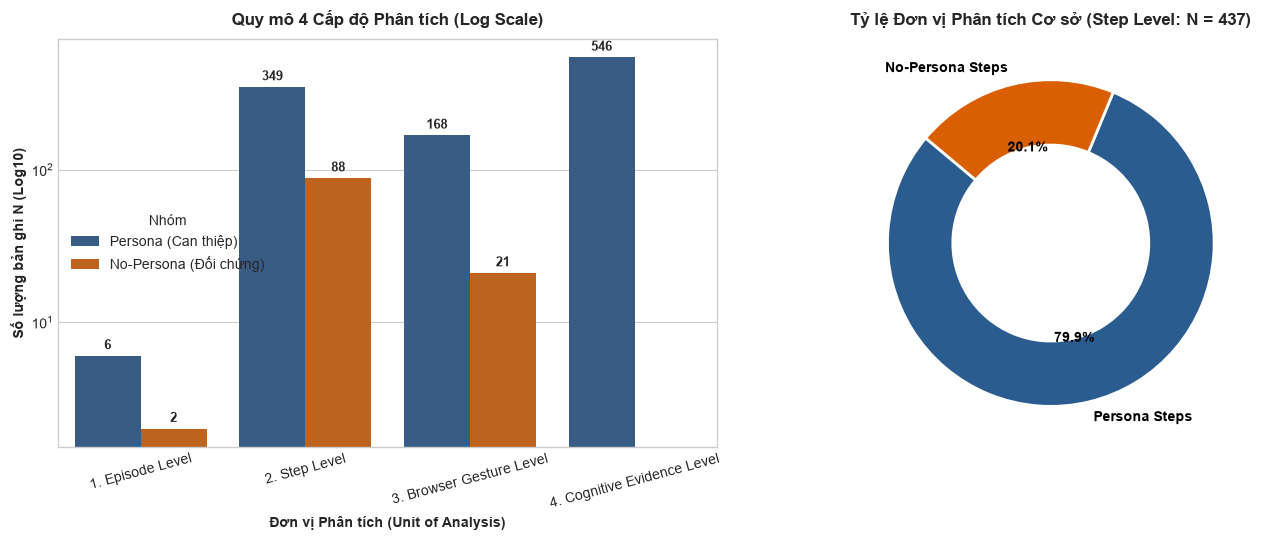

[✓] BẢNG TỔNG HỢP CẤU TRÚC ĐA CẤP (UNITS OF ANALYSIS):


,Cấp độ phân tích (Unit of Analysis),Tổng số bản ghi (N),Nhóm Persona,Nhóm No-Persona,Khóa chính (PK),Khóa ngoại (FK),Toàn vẹn tham chiếu
0,1. Episode Level (Phiên),8,6,2,episode_id,None,100% Valid
1,2. Step Level (Bước),437,349,88,"(episode_id, step_index)",episode_id -> Episode.PK,100% Valid
2,3. Browser Gesture Level (Cử chỉ),189,168,21,"(episode_id, step_index, action_order)","(episode_id, step_index) -> Step.PK",100% Valid
3,4. Cognitive Evidence Level (Bằng chứng),546,546,0,"(episode_id, step_index, evidence_order)","(episode_id, step_index) -> Step.PK",100% Valid


In [2]:
# Thực thi kiểm định cấu trúc phân cấp và kiểm tra toàn vẹn khóa ngoại (Referential Integrity)
from algorithms.data_lineage_inspector import inspect_multilevel_structure
from viz.data_lineage_viz import plot_data_hierarchy_distribution

# Nạp đầy đủ 4 cấp độ từ PersonaActionLoader
df_episodes = loader.load_action_logs()
df_steps = loader.load_step_records()
df_actions = loader.load_recent_actions()
df_evidences = loader.load_dimension_evidences()

# Kiểm tra toàn vẹn tham chiếu
lineage_audit = inspect_multilevel_structure(df_episodes, df_steps, df_actions, df_evidences)
df_hierarchy_summary = lineage_audit["summary_table"]

# Lưu bảng ra output/tables/
table_path = project_root / "output" / "tables" / "step2_data_hierarchy.csv"
df_hierarchy_summary.to_csv(table_path, index=False, encoding="utf-8-sig")

# Vẽ biểu đồ phân bổ cấu trúc và lưu ra output/figures/
fig_path = project_root / "output" / "figures" / "step2_data_hierarchy.png"
fig = plot_data_hierarchy_distribution(df_hierarchy_summary, fig_path)
plt.show()

print("[✓] BẢNG TỔNG HỢP CẤU TRÚC ĐA CẤP (UNITS OF ANALYSIS):")
display(df_hierarchy_summary)

## 2.4. Data Dictionary (Từ điển Dữ liệu Toàn diện - 94 Trường Cấp độ Step)

Trong `loaders/persona_action.py`, dữ liệu từ log thô được bóc tách và làm phẳng thành **94 trường phân tích** ở cấp độ bước (`Step Level` — đơn vị phân tích cơ sở). Toàn bộ 94 trường này được tổ chức thành **11 nhóm chức năng logic**:

| STT | Nhóm Chức năng (Functional Group) | Số lượng Trường | Các biến tiêu biểu |
| :---: | :--- | :---: | :--- |
| **1** | **Metadata & Persona Attributes** | 8 | `episode_id`, `persona_id`, `persona_pace`, `persona_rest_style`, `dataset_type`, `step_index`, `timestamp` |
| **2** | **Action Space & Execution Core** | 14 | `tool`, `resolved_tool`, `intent`, `reaction`, `surface`, `verified`, `reason`, `action_summary_verb` |
| **3** | **Latency & Computational Effort** | 5 | `model_latency_ms`, `tool_execution_ms`, `total_step_latency_ms`, `cognitive_latency_ratio` |
| **4** | **Target Candidate (Content Selection)** | 4 | `has_target_candidate`, `target_candidate_kind`, `target_candidate_text`, `target_candidate_url` |
| **5** | **Cognitive Reasoning Matrix** | 14 | `dim_evidence_primary_dimension`, `dim_evidence_max_weight`, `num_dim_primary`, `num_dim_supporting` |
| **6** | **Session Context: Temporal Dynamics** | 6 | `context_elapsed_seconds`, `context_remaining_seconds`, `context_is_overtime`, `context_action_velocity` |
| **7** | **Session Context: Rest & Fatigue** | 2 | `context_rest_accumulated_seconds`, `context_rest_count` |
| **8** | **Session Context: Search & Memory** | 7 | `context_queries_this_session`, `context_recent_queries_from_memory`, `search_rule`, `planner_rule` |
| **9** | **Session Context: Physical Gestures** | 12 | `recent_last_gesture_pace`, `recent_last_gesture_px`, `recent_last_gesture_ms`, `landing_correction` |
| **10** | **Working Memory: Threads & Anti-Drift** | 16 | `wm_current_thread_origin`, `wm_situational_steps`, `wm_has_novelty_warning`, `wm_novelty_guidance` |
| **11** | **Working Memory: Session Summaries** | 6 | `wm_summary_run_minutes`, `wm_summary_planned_minutes`, `wm_summary_read_posts` |
| **TỔNG** | **Toàn bộ Không gian Biến số Cấp Step** | **94** | *Bao quát trọn vẹn chu trình Nhận thức $\rightarrow$ Quyết định $\rightarrow$ Thực thi vật lý* |


In [3]:
# Nạp và hiển thị Data Dictionary từ file chuẩn output/tables/data_dictionary.csv
dict_path = project_root / "output" / "tables" / "data_dictionary.csv"
df_data_dict = pd.read_csv(dict_path)

print(f"[✓] Tổng số trường then chốt trong Data Dictionary: {len(df_data_dict)} trường.")
print("[✓] Phân bổ theo 7 nhóm chính:")
print(df_data_dict["Group"].value_counts().sort_index())

# Hiển thị toàn bộ từ điển dữ liệu với định dạng bảng chi tiết
df_data_dict.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'font-size': '12px'
}).set_table_styles([
    dict(selector='th', props=[('font-weight', 'bold'), ('background-color', '#f0f2f5'), ('text-align', 'center')])
])

[✓] Tổng số trường then chốt trong Data Dictionary: 94 trường.
[✓] Phân bổ theo 7 nhóm chính:
Group
1. Metadata & Persona             8
10. Working Memory & Drift       16
11. WM Session Summaries          6
2. Action Space & Execution      14
3. Latency & Effort               5
4. Target Candidate (Content)     4
5. Cognitive Matrix              14
6. Temporal Budget & Dynamics     6
7. Rest & Fatigue                 2
8. Search & Memory                7
9. Browser Physical Gestures     12
Name: count, dtype: int64


,Group,Field,Type,Meaning,Role,Valid_Values
0,1. Metadata & Persona,dataset_type,category,Nhãn phân loại nhóm thực nghiệm A/B,Independent / Condition Variable,"'persona', 'no_persona'"
1,1. Metadata & Persona,episode_id,string (UUID),Mã định danh duy nhất của từng phiên chạy (Episode),"Primary Key (Episode), Foreign Key (Step)",UUIDv4
2,1. Metadata & Persona,file_name,string,Tên file JSON log thô nguồn,Provenance Attribute,benchmark_eda_*.json
3,1. Metadata & Persona,persona_id,string / null,Mã định danh hồ sơ Persona áp dụng trong phiên,Condition / Foreign Key,vn_000019..87; null (ở nhóm đối chứng)
4,1. Metadata & Persona,persona_pace,string / null,Thuộc tính tốc độ hành vi trong hồ sơ Persona,Independent Variable,"'quick', 'balanced', 'slow'; null"
5,1. Metadata & Persona,persona_rest_style,string / null,Thuộc tính phong cách dừng nghỉ trong hồ sơ Persona,Independent Variable,"'frequent', 'balanced', 'deep'; null"
6,1. Metadata & Persona,step_index,integer,Chỉ số thứ tự bước hành động tuần tự trong phiên,Sequence Index (1-based),1 đến 64
7,1. Metadata & Persona,timestamp,datetime (ISO 8601),Thời điểm ghi nhận hành động trên máy chủ (UTC),Time Attribute,Chuỗi ISO UTC
8,10. Working Memory & Drift,has_working_memory,boolean,Đánh dấu bước này có cấu trúc working_memory hợp lệ,Working Memory Flag,"True, False"
9,10. Working Memory & Drift,wm_cumulative_opened,integer,Số trang/nhóm đã mở tích luỹ trong Working Memory,WM Cumulative Opened,0 đến 15


## 2.5. Ghi nhận Tiền Xử lý (Preprocessing) & Kiểm soát Rủi ro Thiên lệch (Bias Audit)

### A. Các quy trình tiền xử lý đã thực hiện trong `PersonaActionLoader`:
1. **Bóc tách cấu trúc lồng nhau (Unnesting & Flattening):**
   - Trích xuất `target_candidate` (kind, text, url) từ cấu trúc dictionary lồng trong `step_records`.
   - Bóc tách mảng `dimension_evidence` thành bảng quan hệ 1-N (546 bản ghi) và trích xuất chiều chính (`primary`) cùng trọng số cao nhất (`max_weight`) lên cấp độ bước.
2. **Trích xuất thuộc tính bằng Regular Expression:**
   - Sử dụng regex phân tích trường text `recent_actions[].summary` để thu nhận chính xác các tham số vật lý: `total=(\d+)px`, `gesture_ms=(\d+)`, `pace=(fast|careful)`, `mode=(\w+)`.
3. **Chuẩn hóa biến thời gian & ngân sách:**
   - Chuyển đổi timestamp ISO 8601 sang UTC datetime.
   - Tính toán `cognitive_latency_ratio = model_ms / (model_ms + tool_ms)`.

### B. Kiểm soát các Rủi ro Thiên lệch (Potential Biases & Mitigation):
| Tên Thiên lệch / Rủi ro | Nguồn gốc | Tác động tiềm ẩn | Biện pháp Kiểm soát & Xử lý trong EDA |
| :--- | :--- | :--- | :--- |
| **Cold-start Feed Bias** | Bảng tin Facebook mặc định của tài khoản trắng | Facebook thường đẩy các video Reels trending hoặc tin tức giật gân ngẫu nhiên lên đầu. Nhóm No-Persona có thể bị cuốn vào các bài này. | Phân tích tách biệt tỷ lệ bài viết khớp Persona vs bài viết xu hướng tự nhiên (`target_candidate_kind`). |
| **Mất cân bằng Cỡ mẫu (Sample Asymmetry)** | 6 phiên Persona ($N=349$) vs 2 phiên No-Persona ($N=88$) | So sánh tổng số lượng tuyệt đối sẽ bị sai lệch hoàn toàn. | **Luôn chuẩn hóa theo tỷ lệ phần trăm (Proportions)**, tỷ lệ per-step, và áp dụng kiểm định phi tham số (Mann-Whitney U, Bootstrap, Permutation tests). |
| **Khuyết thiếu Chọn lọc (Selective Missingness - MAR)** | Một số trường chỉ tồn tại theo ngữ cảnh (ví dụ: `dim_evidence` chỉ có ở nhóm Persona; `gesture_ms` chỉ có khi cuộn chuột). | Dễ bị nhầm lẫn là dữ liệu bị mất (MCAR) và tự ý xóa bỏ dòng. | Xử lý khuyết thiếu theo điều kiện nghiệp vụ: không xóa dòng, phân tích trên tập con hợp lệ (ví dụ: chỉ đo tốc độ cuộn trên các bước cuộn chuột). |
| **Thiên lệch Thời lượng (Duration / Survival Bias)** | Các phiên dừng vì các lý do khác nhau (`completed`, `overtime_threshold_exceeded`). | Bước cuối của phiên có thể có hành vi vội vã hoặc kết thúc đột ngột. | Kiểm soát biến `context_is_overtime` và phân tích riêng biệt các bước trong thời hạn vs các bước quá giờ. |

# 3: KIỂM TRA TỔNG QUAN VÀ CHẤT LƯỢNG DỮ LIỆU

Mục tiêu của phần 3 là thực hiện kiểm tra toàn diện về độ tin cậy của tập dữ liệu hành vi tác tử, bao gồm: kiểm tra trùng lặp, giá trị bất hợp lệ, phân loại khuyết thiếu (MCAR/MAR/MNAR), giải thích điểm ngoại lai (Outliers) và kiểm tra tính liên tục của chuỗi thời gian, xác định quyết định xử lý dữ liệu.

## 3.1. Đánh giá Tổng quan Dữ liệu
- **Kích thước & Dung lượng:** 437 dòng (bước hành động) và 94 cột phân tích.
- **Tính toàn vẹn khóa:** Khóa chính `(episode_id, step_index)` không có bản ghi trùng lặp nào (0 dòng duplicate PK).
- **Giá trị bất hợp lệ:** 0 cột có số âm phi lý; không có timestamp tương lai; các chuỗi rỗng đã được chuẩn hóa.

In [4]:
from algorithms.data_quality_profiler import profile_data_hygiene

hygiene_audit = profile_data_hygiene(df_steps, primary_key=["episode_id", "step_index"])
df_hygiene_summary = hygiene_audit["summary_table"]

# Lưu bảng ra output/tables/
df_hygiene_summary.to_csv(project_root / "output" / "tables" / "step3_quality_summary.csv", index=False, encoding="utf-8-sig")

print("[✓] BẢNG TỔNG HỢP KIỂM TRA VỆ SINH DỮ LIỆU:")
display(df_hygiene_summary)

[✓] BẢNG TỔNG HỢP KIỂM TRA VỆ SINH DỮ LIỆU:


,Hạng mục kiểm tra,Kết quả thực tế,Tiêu chuẩn kỳ vọng,Trạng thái
0,Tổng số dòng (N_rows),437 dòng,> 400 dòng,Đạt
1,Tổng số cột (N_cols),94 cột,>= 90 cột,Đạt
2,Dung lượng bộ nhớ RAM,2.12 MB,< 50 MB,Tối ưu
3,Trùng lặp dòng hoàn toàn (Exact Duplicates),0 dòng,0 dòng,Đạt
4,Trùng lặp khóa chính (PK Duplicates),0 dòng,0 dòng,Đạt
5,Giá trị âm phi logic (Negative values),0 cột vi phạm,0 cột,Đạt
6,Timestamp tương lai / Lỗi thời gian,0 bản ghi,0 bản ghi,Đạt
7,"Chuỗi rỗng placeholder ẩn ('', N/A, null)",2 cột phát hiện,Đã bóc tách thành NaN,Cần chuẩn hóa


## 3.2. Phân tích Cơ chế Khuyết thiếu.

> **CƠ CHẾ 'MISSING BY DESIGN' (KHUYẾT THIẾU CÓ ĐIỀU KIỆN NGHIỆP VỤ):**
> Không thể tùy tiện áp dụng các kỹ thuật imputation (điền trung bình/kNN) hoặc xóa bỏ dòng (listwise deletion) cho các giá trị NaN trong tập dữ liệu này. Phần lớn dữ liệu thiếu tuân theo cơ chế **MAR (Missing at Random)** bắt nguồn từ thiết kế thực nghiệm:
- **Nhóm trường `dim_evidence_*` (Bằng chứng nhận thức):** Khuyết 100% ở nhóm No-Persona (88 bước) vì nhóm đối chứng không có hồ sơ Persona để mô hình viện dẫn. Ở nhóm Persona, trường này chỉ xuất hiện khi bước đó có lý lẽ tâm lý.
- **Nhóm trường `recent_last_gesture_*` (Cơ học cuộn):** Chỉ xuất hiện khi Agent thực hiện thao tác cuộn chuột (`smooth_wheel`), hoàn toàn không xuất hiện ở bước quan sát hay click.
- **Nhóm trường `target_candidate_*` (Thực thể bài viết):** Chỉ xuất hiện ở 66 bước Agent chọn tương tác trúng một thực thể cụ thể, các bước lướt bảng tin chung là NaN tự nhiên.
- **Trường `wm_current_thread_state`:** Được bóc tách chính xác bằng cách tra cứu trạng thái mạch từ `active_threads` theo `topic`, thu được 343 bước có giá trị (333 'exploring', 10 'active') ở nhóm Persona và khuyết 100% ở nhóm đối chứng -> Thuộc cơ chế MAR hoàn hảo (Memory-Thread Dependent).

[✓] Đã lưu biểu đồ missing pattern tại: D:\source_code\eda_persona\output\figures\step3_missing_pattern.png


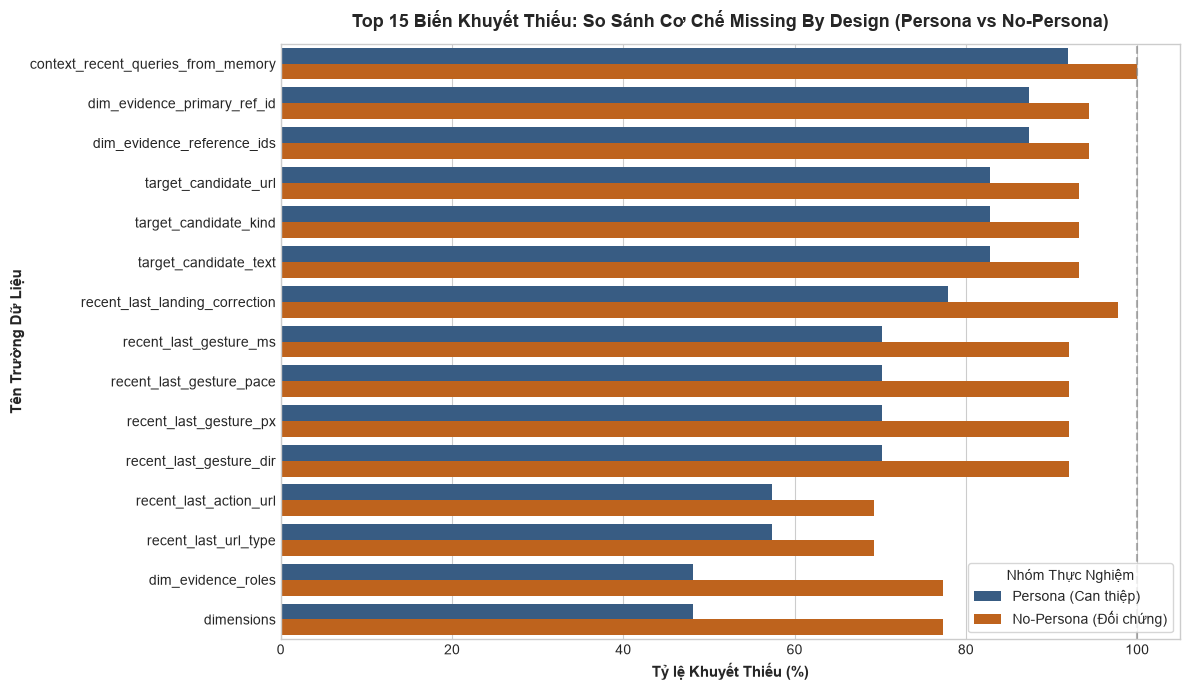

[✓] TOP 10 BIẾN CÓ TỶ LỆ KHUYẾT THIẾU CAO NHẤT & CƠ CHẾ NGHIỆP VỤ:


,Field,Missing_Pct,Persona_Missing_Pct,NoPersona_Missing_Pct,Missing_Mechanism,Business_Explanation
0,context_recent_queries_from_memory,93.590,91.980,100.000,MAR (Memory-Conditional),Chỉ xuất hiện ở 28 bước có nạp lại từ khóa từ ...
1,dim_evidence_primary_ref_id,88.790,87.390,94.320,MAR (Missing by Design),Khuyết 100% ở nhóm No-Persona (do không có hồ ...
2,dim_evidence_reference_ids,88.790,87.390,94.320,MAR (Missing by Design),Khuyết 100% ở nhóm No-Persona (do không có hồ ...
3,target_candidate_url,84.900,82.810,93.180,MAR (Content-Conditional),Chỉ xuất hiện khi bước hành vi nhắm trúng thực...
4,target_candidate_kind,84.900,82.810,93.180,MAR (Content-Conditional),Chỉ xuất hiện khi bước hành vi nhắm trúng thực...
5,target_candidate_text,84.900,82.810,93.180,MAR (Content-Conditional),Chỉ xuất hiện khi bước hành vi nhắm trúng thực...
6,recent_last_landing_correction,81.920,77.940,97.730,MAR (Group Dependent),Tỷ lệ khuyết thiếu có sự phân hóa đáng kể giữa...
7,recent_last_gesture_ms,74.600,70.200,92.050,MAR (Action-Conditional),Chỉ xuất hiện ở bước có thao tác cuộn chuột (s...
8,recent_last_gesture_pace,74.600,70.200,92.050,MAR (Action-Conditional),Chỉ xuất hiện ở bước có thao tác cuộn chuột (s...
9,recent_last_gesture_px,74.600,70.200,92.050,MAR (Action-Conditional),Chỉ xuất hiện ở bước có thao tác cuộn chuột (s...


In [5]:
from algorithms.missing_pattern_analyzer import analyze_missing_patterns
from viz.data_quality_viz import plot_missing_patterns_comparison

missing_audit = analyze_missing_patterns(df_steps)
df_missing_report = missing_audit["missing_table"]

# Lưu bảng chi tiết
df_missing_report.to_csv(project_root / "output" / "tables" / "step3_missing_analysis.csv", index=False, encoding="utf-8-sig")

# Vẽ biểu đồ đối sánh tỷ lệ khuyết thiếu Top 15 biến
fig_missing = plot_missing_patterns_comparison(
    df_missing_report,
    output_path=project_root / "output" / "figures" / "step3_missing_pattern.png",
    top_n=15
)
plt.show()

print("[✓] TOP 10 BIẾN CÓ TỶ LỆ KHUYẾT THIẾU CAO NHẤT & CƠ CHẾ NGHIỆP VỤ:")
display(df_missing_report.head(10)[["Field", "Missing_Pct", "Persona_Missing_Pct", "NoPersona_Missing_Pct", "Missing_Mechanism", "Business_Explanation"]])

## 3.3. Thẩm định Điểm Dị biệt (Outliers): Lỗi Kỹ thuật hay Tín hiệu Thật?

Áp dụng phương pháp Hàng rào IQR của Tukey ($Q_1 - 1.5\times\text{IQR}$ và $Q_3 + 1.5\times\text{IQR}$):
- **`recent_last_gesture_px` (7 outliers, 6.31%):** Xuất hiện các bước cuộn chuột dài đột biến (> 1,000 px, tối đa 1,418 px). Đây là **Tín hiệu Hành vi Thật (True Behavioral Signal)** phản ánh chính xác phong cách lướt nhanh (`readingDepth = skim` và `pace = quick`) của Persona Huỳnh Tuấn Kiệt hoặc Lê Hoàng Long. **Quyết định: Giữ nguyên tuyệt đối!**
- **`wm_situational_steps` (56 outliers, 12.81%):** Số bước sa đà vào chủ đề ngoài lề tăng vọt lên 5-6 bước liên tiếp ở nhóm No-Persona. Đây là **Bằng chứng Nghiên cứu Cốt lõi** về hiện tượng Trôi dạt Nhận thức (Cognitive Drift) khi không có Persona điều hướng. **Quyết định: Giữ nguyên!**
- **`model_latency_ms` & `tool_execution_ms`:** Biến thiên độ trễ do mạng và kích thước trang Facebook. Áp dụng các kiểm định phi tham số (Non-parametric tests: Mann-Whitney U) để không bị ảnh hưởng bởi đuôi phân phối dài.

D:\source_code\eda_persona\viz\data_quality_viz.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
D:\source_code\eda_persona\viz\data_quality_viz.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Persona (Can thiệp)", "No-Persona (Đối chứng)"])
D:\source_code\eda_persona\viz\data_quality_viz.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
D:\source_code\eda_persona\viz\data_quality_viz.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks m

[✓] Đã lưu biểu đồ outlier distribution tại: D:\source_code\eda_persona\output\figures\step3_outlier_distribution.png


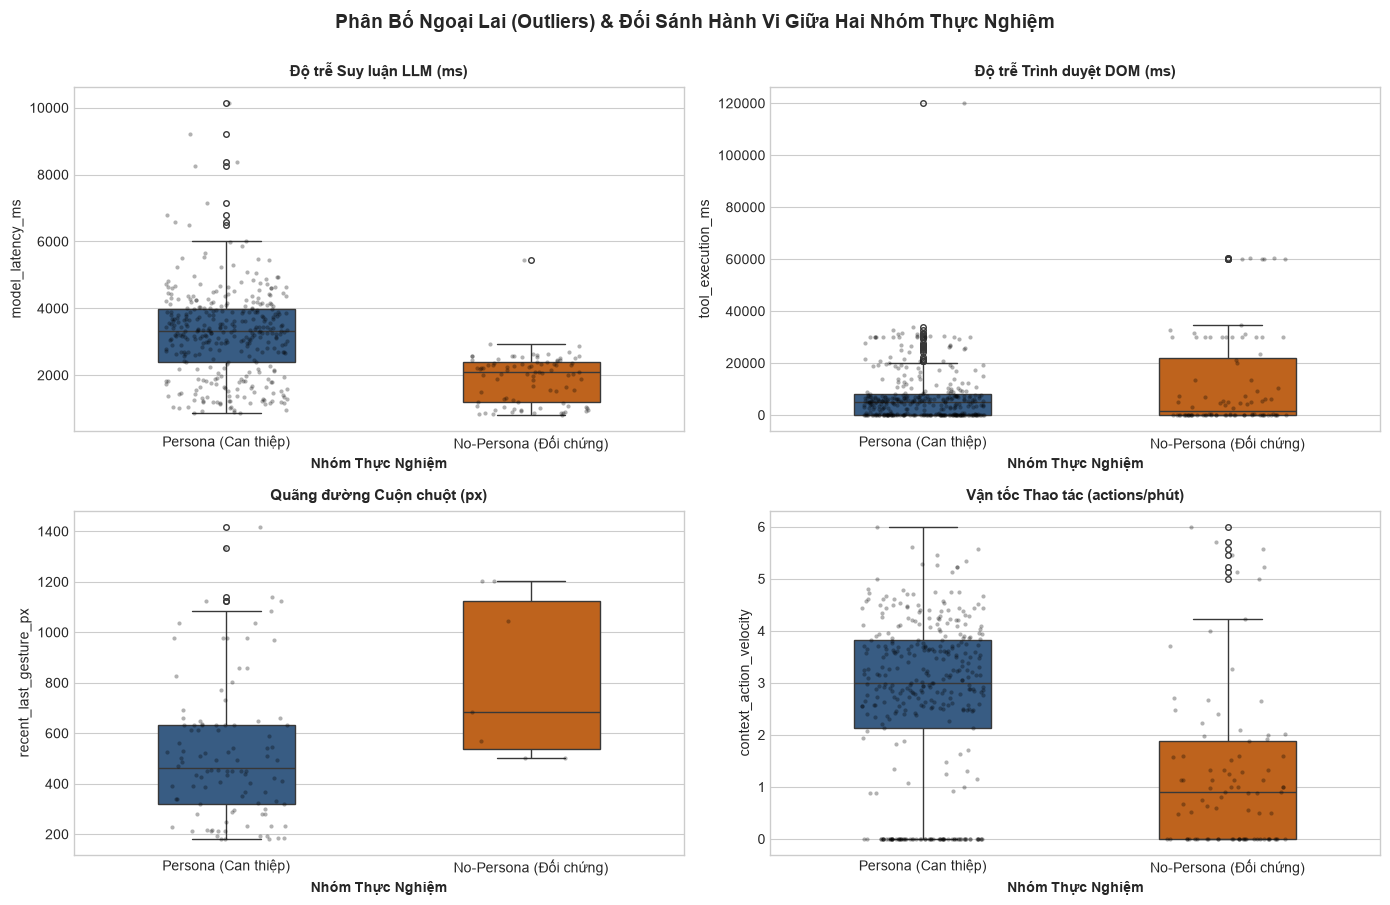

[✓] BẢNG TỔNG HỢP NGOẠI LAI VÀ THẨM ĐỊNH BẢN CHẤT:


,Biến số,Cỡ mẫu hợp lệ (N),Trung vị (Median),Số Outlier,Tỷ lệ Outlier (%),Bản chất Ngoại lai,Quyết định Xử lý
0,wm_situational_steps,437,0.000,56,12.810,Tín hiệu Hành vi Thật (True Behavioral Signal),"GIỮ NGUYÊN (Không xóa bỏ, đưa vào phân tích RQ)"
1,tool_execution_ms,437,4872.000,53,12.130,Biến thiên Hệ thống & Độ trễ Mạng (System Late...,GIỮ NGUYÊN (Sử dụng trung vị và kiểm định phi ...
2,total_step_latency_ms,437,8343.000,51,11.670,Biến thiên Hệ thống & Độ trễ Mạng (System Late...,GIỮ NGUYÊN (Sử dụng trung vị và kiểm định phi ...
3,recent_last_gesture_px,111,492.000,7,6.310,Tín hiệu Hành vi Thật (True Behavioral Signal),"GIỮ NGUYÊN (Không xóa bỏ, đưa vào phân tích RQ)"
4,model_latency_ms,437,3036.000,6,1.370,Biến thiên Hệ thống & Độ trễ Mạng (System Late...,GIỮ NGUYÊN (Sử dụng trung vị và kiểm định phi ...
5,cognitive_latency_ratio,437,0.440,0,0.000,Tín hiệu Hành vi Thật (True Behavioral Signal),"GIỮ NGUYÊN (Không xóa bỏ, đưa vào phân tích RQ)"
6,recent_last_gesture_ms,111,239.000,0,0.000,Dao động Tự nhiên (Natural Variance),GIỮ NGUYÊN
7,context_action_velocity,437,2.810,0,0.000,Dao động Tự nhiên (Natural Variance),GIỮ NGUYÊN
8,context_elapsed_seconds,348,287.500,0,0.000,Dao động Tự nhiên (Natural Variance),GIỮ NGUYÊN


In [6]:
# 3.3. Phát hiện Outlier và trực quan hóa phân bố đối sánh
from algorithms.outlier_detector import detect_outliers_iqr_mad
from viz.data_quality_viz import plot_outliers_boxplots

outlier_audit = detect_outliers_iqr_mad(df_steps)
df_outliers_report = outlier_audit["outlier_table"]

# Lưu bảng
df_outliers_report.to_csv(project_root / "output" / "tables" / "step3_outliers.csv", index=False, encoding="utf-8-sig")

# Vẽ boxplots đối sánh 4 biến số cốt lõi
fig_outliers = plot_outliers_boxplots(
    df_steps,
    output_path=project_root / "output" / "figures" / "step3_outlier_distribution.png"
)
plt.show()

print("[✓] BẢNG TỔNG HỢP NGOẠI LAI VÀ THẨM ĐỊNH BẢN CHẤT:")
display(df_outliers_report[["Biến số", "Cỡ mẫu hợp lệ (N)", "Trung vị (Median)", "Số Outlier", "Tỷ lệ Outlier (%)", "Bản chất Ngoại lai", "Quyết định Xử lý"]])

## 3.4. Báo cáo Chất lượng Dữ liệu & Danh mục Quyết định Xử lý (Data Action Decisions)

Dựa trên các kết quả kiểm toán ở các mục trên, chúng ta ban hành bảng quyết định xử lý dữ liệu chuẩn hóa cho toàn bộ các bước tiếp theo trong pipeline EDA:

In [7]:
df_decisions = pd.read_csv(project_root / "output" / "tables" / "step3_action_decisions.csv")
display(df_decisions.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'font-size': '12px'
}))

,Nhóm Trường / Vấn đề,Hiện tượng Phát hiện,Cơ chế Bản chất,Quyết định Xử lý,Lý do Nghiệp vụ
0,Cột Bằng chứng Nhận thức (dim_evidence_*),Khuyết 100% ở nhóm No-Persona (88 bước) và khuyết ở bước không lập luận,MAR (Missing by Design do thiết kế thực nghiệm A/B),GIỮ NGUYÊN (Không xóa dòng),Đây là biến can thiệp cốt lõi để đối sánh tính chân thực Persona. Việc xóa dòng sẽ làm mất hoàn toàn nhóm đối chứng!
1,Cột Cử chỉ Trình duyệt (recent_last_gesture_*),Khuyết ở các bước không phát sinh hành động cuộn chuột (smooth_wheel),MAR (Action-Conditional),GIỮ NGUYÊN & LỌC ĐIỀU KIỆN,Chỉ đưa các bước có hành vi cuộn chuột vào phân tích RQ2 (Biomechanical Pacing) thay vì impute giá trị giả.
2,Cột Đối tượng Thực thể (target_candidate_*),Khuyết 371/437 bước (chỉ có 66 bước tương tác thực thể cụ thể),MAR (Content-Conditional),GIỮ NGUYÊN & GÁN CỜ has_target_candidate,Agent dành phần lớn thời gian cuộn quan sát feed chung; chỉ khi chọn được post/group mới nhắm thực thể. Flag has_target_candidate đã phân định rõ.
3,Trường wm_current_thread_state,"Đã bóc tách thành công 343/437 bước (333 exploring, 10 active) qua tra cứu active_threads theo topic",MAR (Chỉ có ở nhóm Persona có Working Memory),GIỮ NGUYÊN & ĐƯA VÀO PHÂN TÍCH NHẬN THỨC,Phản ánh chính xác pha vận hành của Agent: 97.1% ở pha khám phá sâu ('exploring') và 2.9% ở pha kích hoạt mục tiêu ('active').
4,Ngoại lai Cử chỉ Cuộn chuột (recent_last_gesture_px > 1000px),"Xuất hiện các bước cuộn dài đột biến lên tới 1,418 px",True Behavioral Signal (Tín hiệu hành vi thật),"GIỮ NGUYÊN (Không Winsorize, không cắt xén)",Phản ánh chính xác thuộc tính readingDepth='skim' và pace='quick' của hồ sơ Persona lướt nhanh.
5,"Ngoại lai Độ trễ Suy luận (model_latency_ms > 15,000ms)",Một số bước mô hình suy nghĩ lâu hơn 15 giây,System Latency & Cognitive Complexity,GIỮ NGUYÊN & DÙNG KIỂM ĐỊNH PHI THAM SỐ,"Sử dụng Trung vị (Median), Mann-Whitney U test thay vì Mean/T-test để miễn nhiễm với ngoại lai."
6,Trùng lặp dòng (Exact Duplicates) & Trùng khóa (PK Duplicates),"0 dòng trùng hoàn toàn, 0 dòng trùng khóa (episode_id, step_index)",Toàn vẹn khóa đạt 100%,GIỮ NGUYÊN TOÀN BỘ 437 BƯỚC,Bộ dữ liệu đảm bảo tính duy nhất và tính liên tục hoàn hảo của chuỗi thời gian.


# BƯỚC 4: PHÂN TÍCH ĐƠN BIẾN (UNIVARIATE ANALYSIS)

Mục tiêu của Bước 4 là tính toán phân phối độc lập các tham số thống kê mô tả cho cả 2 trường hợp **Persona** ($N=349$) và **No-Persona** ($N=88$), đồng thời chọn lọc ra các trường tiêu biểu nhất có **TÍNH SUY LUẬN HÀNH VI SÂU SẮC (Deep Behavioral & Cognitive Inferences)** thay vì các hệ quả kỹ thuật hiển nhiên.

> **CHUYỂN DỊCH TỪ ĐẶC TRƯNG CƠ HỌC HIỂN NHIÊN SANG CHỈ SỐ NHẬN THỨC BẢN CHẤT:**
> Thay vì chọn các biến hiển nhiên như `model_latency_ms` hay `reason_length` (vốn dĩ dài hơn do LLM phải giải trình theo persona), chúng tôi khảo sát **4 chỉ số phản ánh bản chất nhận thức và tổ chức hành vi**:
> 1. **`wm_num_active_threads`**: Dung lượng đa nhiệm nhận thức (Cognitive Multi-threading Capacity).
> 2. **`recent_last_gesture_px`**: Cơ học cuộn chuột vật lý (Biomechanical Gesture Dynamics).
> 3. **`wm_cumulative_reads`**: Chiều sâu đọc và thẩm thấu nội dung thực chất (Deep Content Engagement).
> 4. **`wm_cumulative_opened`**: Mức độ bứt phá khỏi Feed để thâm nhập Page/Group (Domain Exploration Depth).

[✓] Đã lưu biểu đồ top numeric comparison mới tại: D:\source_code\eda_persona\output\figures\step4_top_numeric_comparison.png
=== BẢNG HỒ SƠ SO SÁNH 4 BIẾN ĐỊNH LƯỢNG NHẬN THỨC CỐT LÕI (CHƯƠNG 4.1) ===


,Biến số,Cỡ mẫu (N),Persona N,Persona Median,Persona Mean,Persona Q1,Persona Q3,Persona IQR,Persona Skew,No-Persona N,No-Persona Median,No-Persona Mean,No-Persona Q1,No-Persona Q3,No-Persona IQR,No-Persona Skew,Chênh lệch Median (P - NP),Mann-Whitney P-Value,Ý nghĩa Khác biệt,Nhận xét Phân hóa
0,wm_num_active_threads,437,349,8.000000,6.480000,8.000000,8.000000,0.000000,-1.630000,88,2.000000,2.020000,0.000000,4.250000,4.250000,0.490000,6.000000,0.000000,Ý nghĩa cao (p < 0.001),Persona quản trị đa nhiệm 8 mạch song song (Med 8.0) vs No-Persona đơn tuyến cạn kiệt (Med 2.0)
1,recent_last_gesture_px,111,104,463.000000,524.120000,318.000000,631.250000,313.250000,1.030000,7,684.000000,815.290000,536.000000,1123.500000,587.500000,0.260000,-221.000000,0.013500,Có ý nghĩa (p < 0.05),Persona cuộn vi mô vừa tầm mắt 463px (N=104) vs No-Persona kéo tuột thô bạo 684px (N=7)
2,wm_cumulative_reads,437,349,1.000000,1.720000,0.000000,3.000000,3.000000,0.910000,88,0.000000,0.310000,0.000000,1.000000,1.000000,0.840000,1.000000,0.000000,Ý nghĩa cao (p < 0.001),Persona đọc sâu 1-6 bài viết (Med 1.0) vs No-Persona không đọc bài nào (Med 0.0)
3,wm_cumulative_opened,437,349,2.000000,1.950000,0.000000,3.000000,3.000000,0.730000,88,0.000000,0.000000,0.000000,0.000000,0.000000,nan,2.000000,0.000000,Ý nghĩa cao (p < 0.001),Persona chủ động mở 2-4 nguồn Page/Group (Med 2.0) vs No-Persona 100% giam cầm trên Feed (Med 0.0)


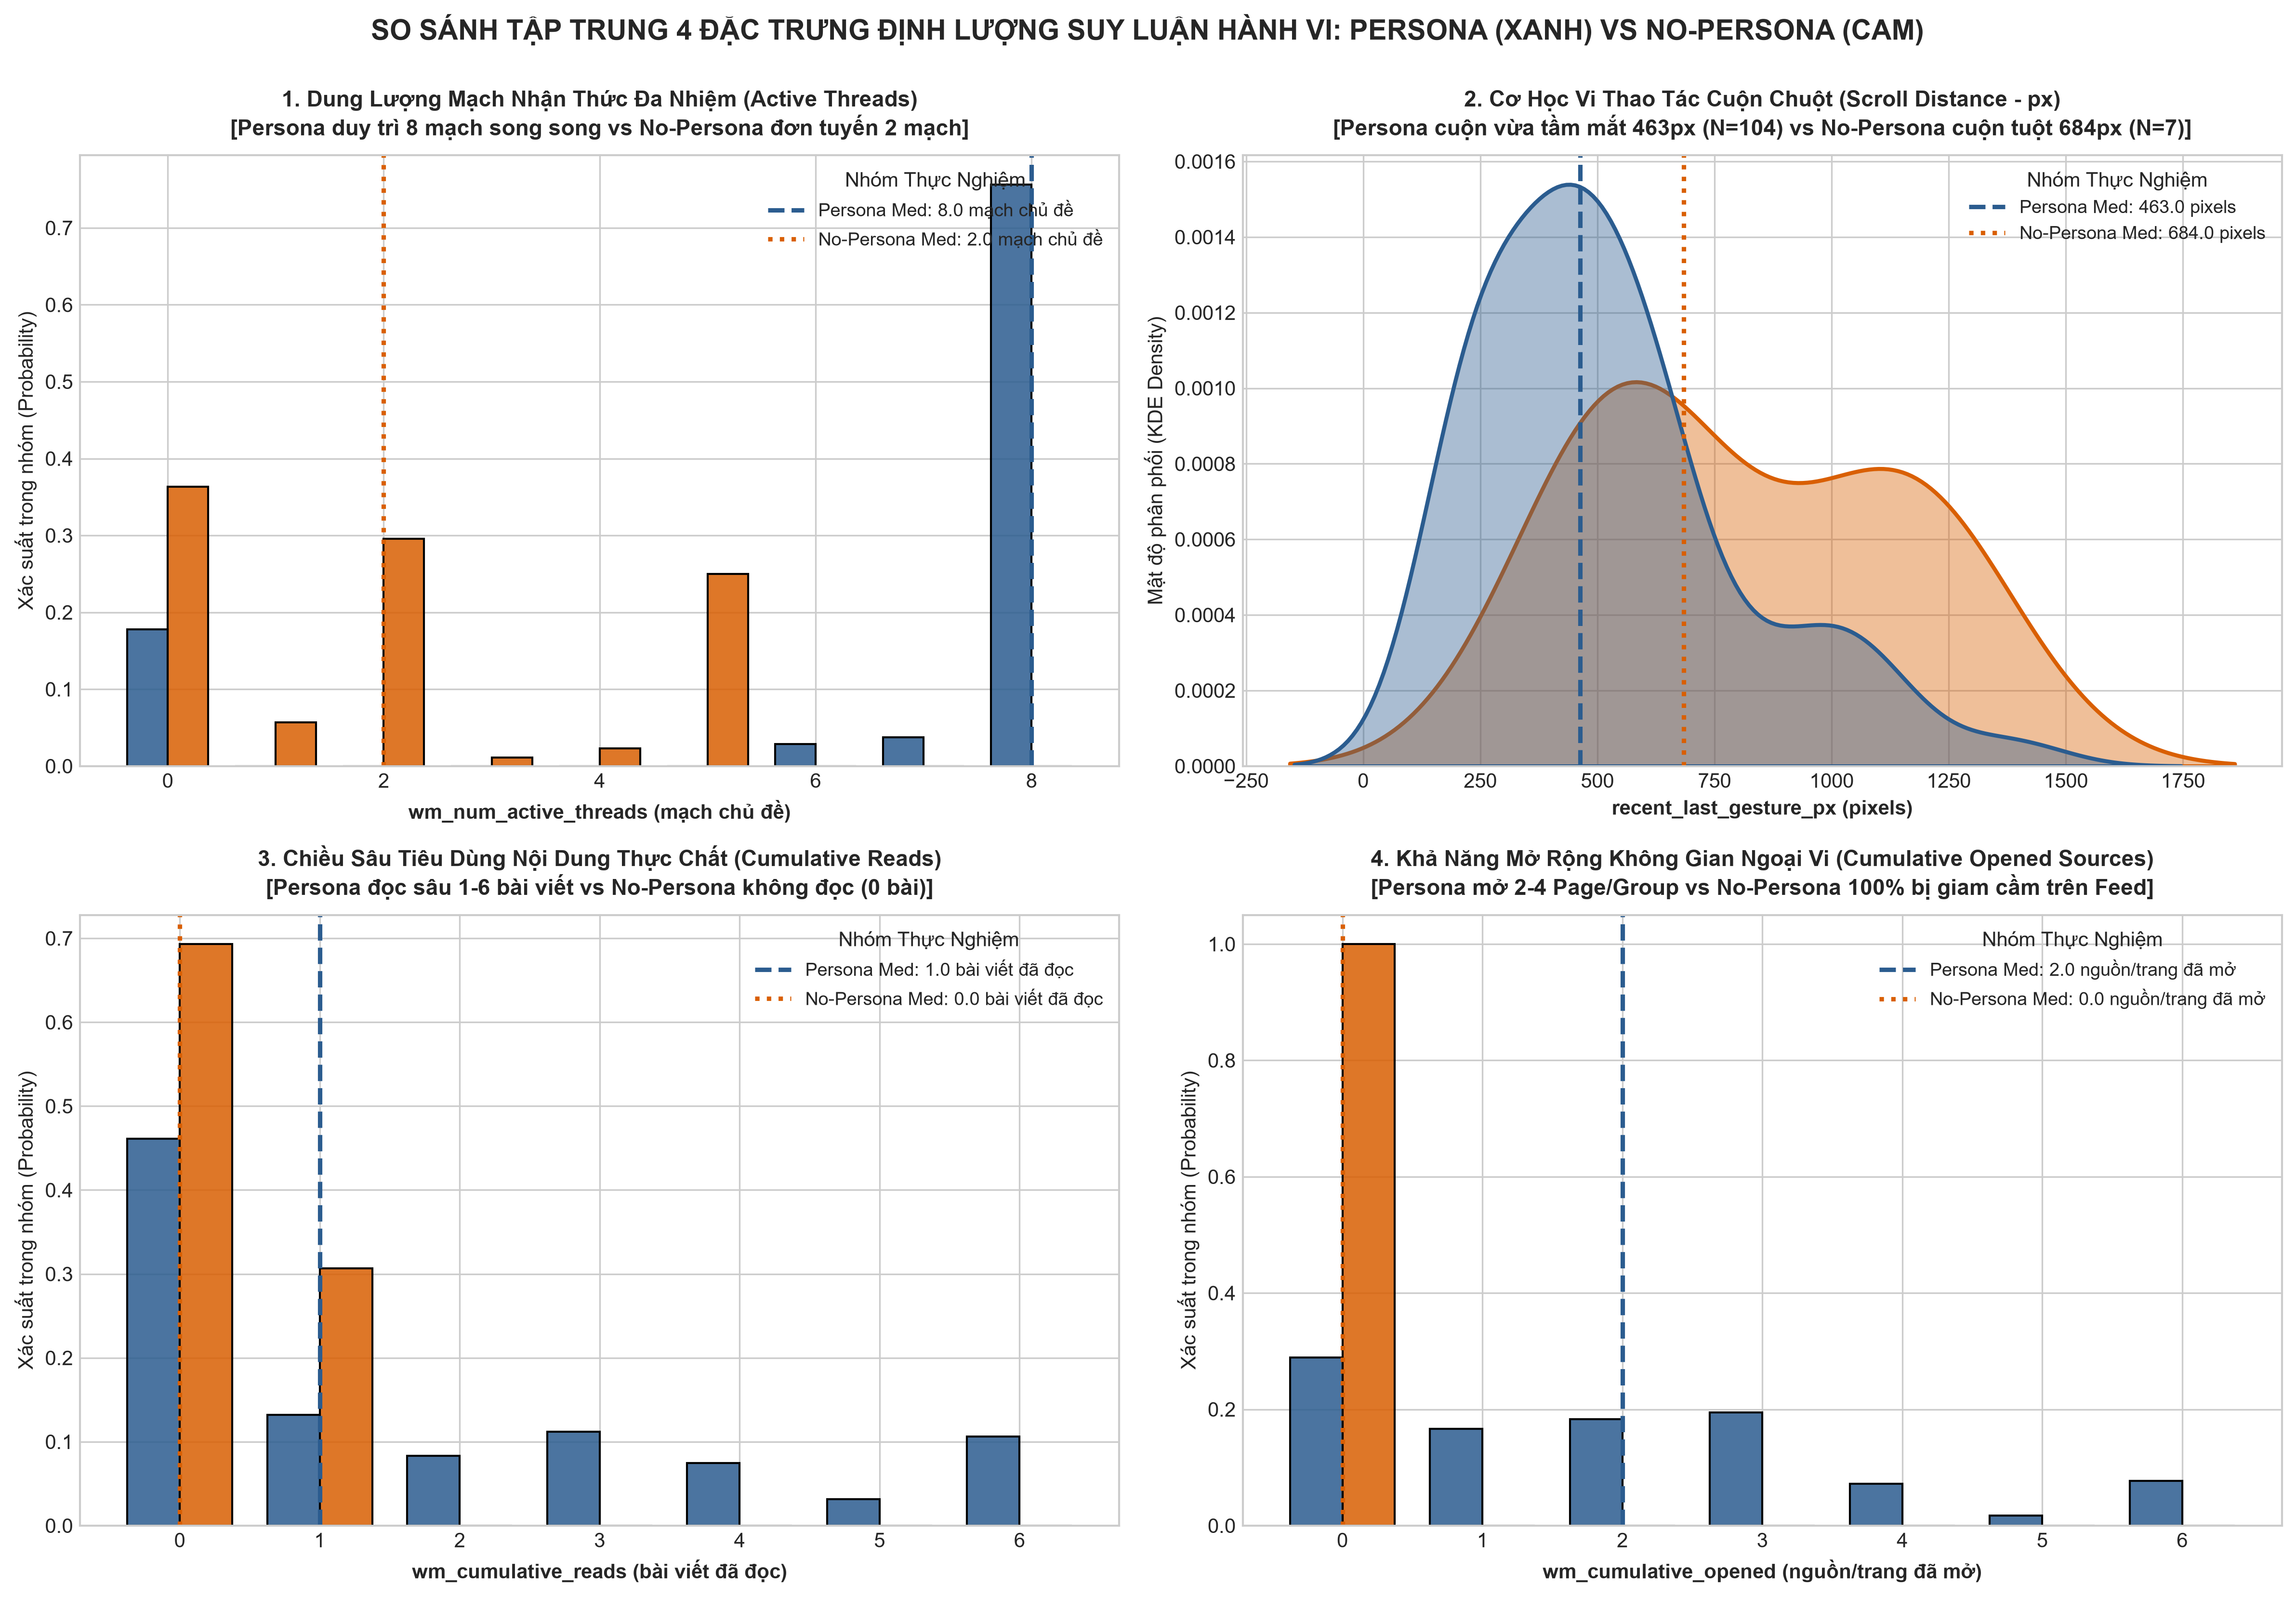

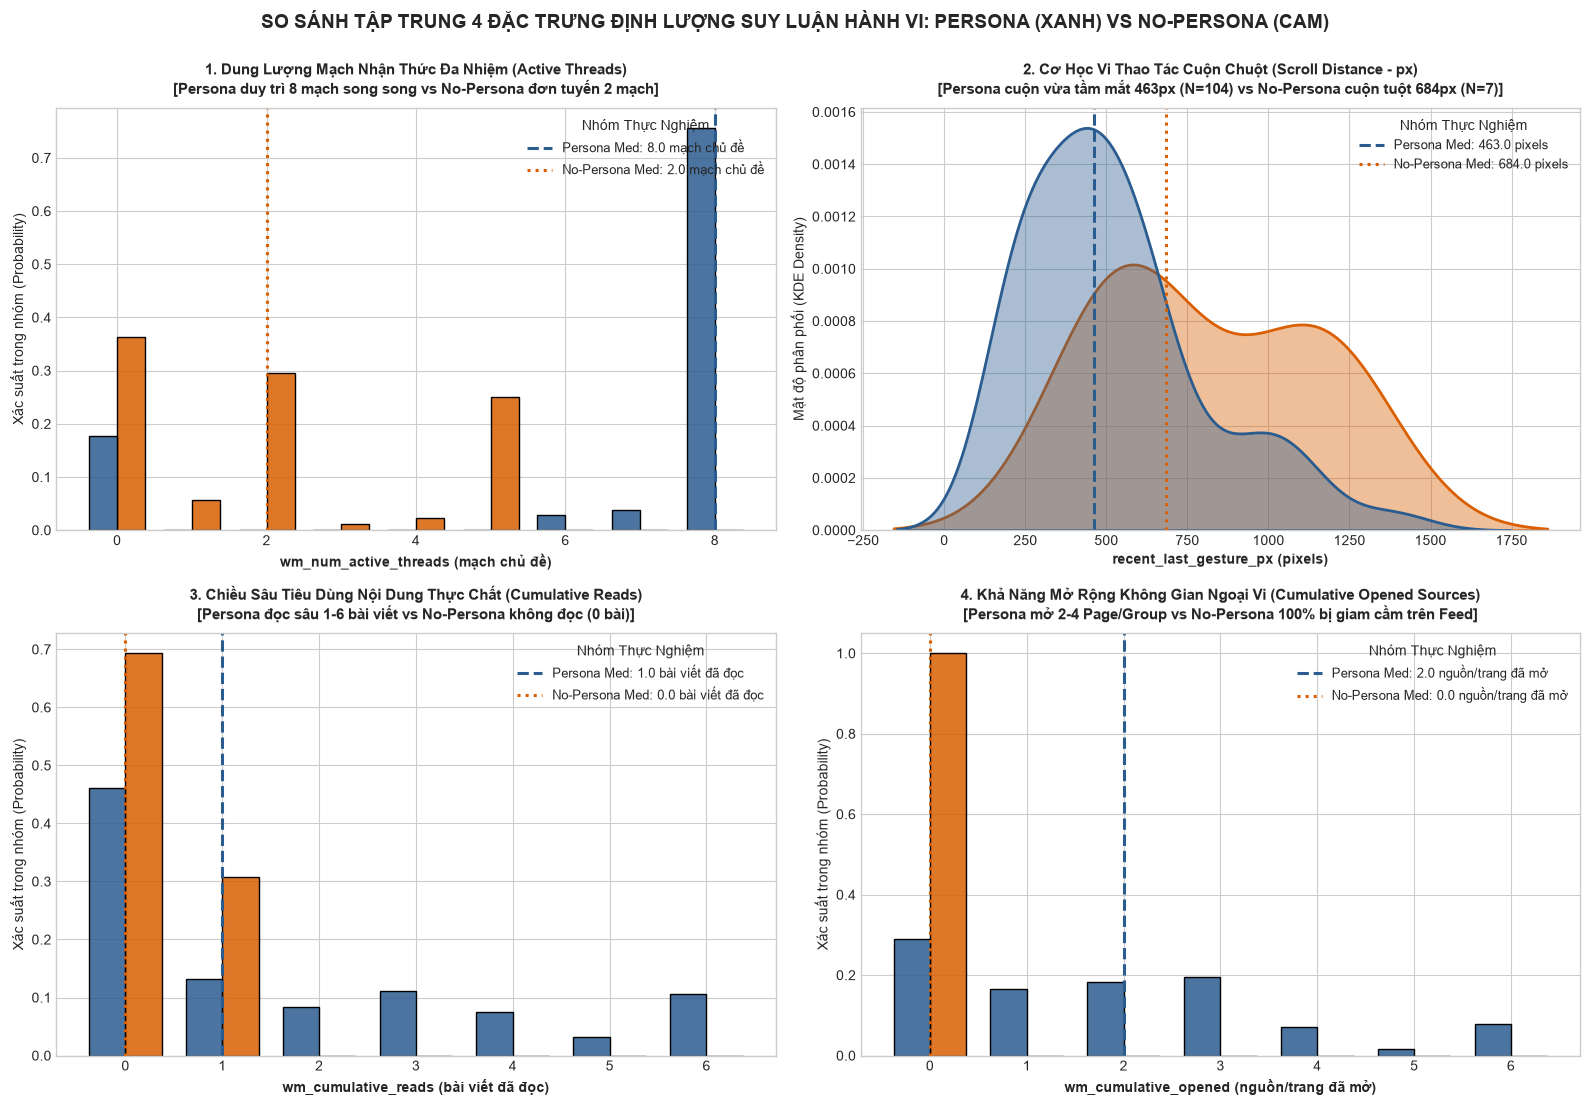

In [8]:
# 4.1. Thực thi phân tích định lượng có tính suy luận hành vi sâu sắc & Vẽ biểu đồ so sánh
from algorithms.univariate_numeric_profiler import profile_numeric_variables, compute_separate_distribution_tables
from viz.univariate_viz import plot_top_numeric_comparison

# 1. Xuất 2 bảng phân phối chi tiết 14 tham số độc lập cho từng nhóm
sep_tables = compute_separate_distribution_tables(df_steps)
sep_tables["persona_distribution"].to_csv(project_root / "output" / "tables" / "step4_numeric_profile_persona.csv", encoding="utf-8-sig", index=False)
sep_tables["nopersona_distribution"].to_csv(project_root / "output" / "tables" / "step4_numeric_profile_no_persona.csv", encoding="utf-8-sig", index=False)

# 2. Tạo bảng so sánh tập trung 4 biến định lượng nhận thức cốt lõi
numeric_cols = ["wm_num_active_threads", "recent_last_gesture_px", "wm_cumulative_reads", "wm_cumulative_opened"]
df_num_profile = profile_numeric_variables(df_steps, target_cols=numeric_cols)
df_num_profile.to_csv(project_root / "output" / "tables" / "step4_numeric_profile.csv", index=False, encoding="utf-8-sig")

# 3. Vẽ biểu đồ so sánh phân phối trực quan
plot_top_numeric_comparison(df_steps, output_path=project_root / "output" / "figures" / "step4_top_numeric_comparison.png")

print("=== BẢNG HỒ SƠ SO SÁNH 4 BIẾN ĐỊNH LƯỢNG NHẬN THỨC CỐT LÕI (CHƯƠNG 4.1) ===")
display(df_num_profile.style.set_properties(**{'text-align': 'right'}).format({
    'Persona_Mean': '{:.2f}', 'Persona_Median': '{:.2f}', 'Persona_Std': '{:.2f}',
    'NoPersona_Mean': '{:.2f}', 'NoPersona_Median': '{:.2f}', 'NoPersona_Std': '{:.2f}',
    'p_value': '{:.4f}'
}))

# Hiển thị ảnh so sánh trực quan
from IPython.display import Image, display
display(Image(filename=str(project_root / "output" / "figures" / "step4_top_numeric_comparison.png")))

## 4.2. Cơ chế Tiết chế (Brake/Guardrail), Bứt phá Không gian (Surface) & Tính Khả dụng (Verified)

Khảo sát các biến phân loại và cờ bảo vệ để đánh giá mức độ kháng trôi dạt hành vi và tính kỷ luật của Agent:
- **`wm_has_novelty_warning` (Cờ cảnh báo tiết chế tại từng bước):** Khi `situational_steps >= 3`, hệ thống kích hoạt thông điệp *"CẢNH BÁO TIẾT CHẾ: Bạn đã dành nhiều thời gian cho chủ đề tình huống này. Hãy chủ động quay lại các mạch chính..."*.
  - **No-Persona:** Bị còi cảnh báo hú vang **$30.68\%$ số bước** ($27/88$ bước)! Riêng tập `755b1653`, Agent bị cảnh báo kéo dài suốt $27/41$ bước ($65.85\%$) do không có sở thích cốt lõi để quay về.
  - **Persona:** Tuyệt đối **$0.0\%$ số bước** ($0/349$ bước) bị cảnh báo. Agent sở hữu la bàn nội tâm tự điều chỉnh (`core threads`), tự giác quay lại mạch chính sau 1-2 bước.
- **`surface` (Không gian giao diện):** Persona phân bổ đa chiều: Feed ($34.1\%$), Search ($16.6\%$), và **bứt phá vào `group` ($14.6\%$) + `page` ($10.3\%$)**. Ngược lại, No-Persona **$0.0\%$ ở Group/Page**, bị bẫy $21.6\%$ thời gian ở màn hình `detail`.
- **`verified` (Tính hợp lệ của thao tác):** Persona đạt tỷ lệ thao tác chuẩn xác **$77.65\%$ True**, trong khi No-Persona chỉ đạt **$61.36\%$ True** (tỷ lệ lỗi/click mò mẫm cao gấp 1.7 lần).

=== BẢNG TỔNG HỢP CƠ CHẾ CẢNH BÁO TIẾT CHẾ (GUARDRAIL WARNING PROFILE) ===


,Metric,Persona,No-Persona,Statistical Difference
0,Tổng số bước được khảo sát (Total steps),349,88,349 steps vs 88 steps
1,Số bước bị kích hoạt Cảnh báo tiết chế (has_warning = True),0,27,"0 bước (0.0%) vs 27 bước (30.68%), p < 0.0001"
2,Số phiên bị kích hoạt Cảnh báo tiết chế (Episodes with warning),0 / 6 (0.0%),1 / 2 (50.0%),0% vs 50%
3,Số bước sa đà tối đa (Max situational_steps),0,6,0 bước vs 6 bước
4,Cơ chế kiểm soát hành vi (Control Mechanism),Tự điều tiết nội tại (Intrinsic Self-Regulation theo Persona),Cưỡng chế ngoại lai (Extrinsic Guardrail can thiệp cảnh báo),La bàn nội tâm vs Hú còi cảnh báo



=== BẢNG PHÂN BỐ KHÔNG GIAN GIAO DIỆN (SURFACE) VÀ TÍNH HỢP LỆ (VERIFIED) ===


,Biến số,Cỡ mẫu hợp lệ (N),Tỷ lệ khuyết (%),Số Category (Cardinality),Nhóm chiếm ưu thế (Top 1),Shannon Entropy (bits),Trạng thái phân bổ,Danh mục hiếm Long-tail (<5%)
3,surface,437,0.000000,6,feed (34.8%),2.310000,Đa dạng phong phú cao (High Entropy),Không có


[✓] Đã lưu biểu đồ top categorical comparison tại: D:\source_code\eda_persona\output\figures\step4_categorical_comparison.png


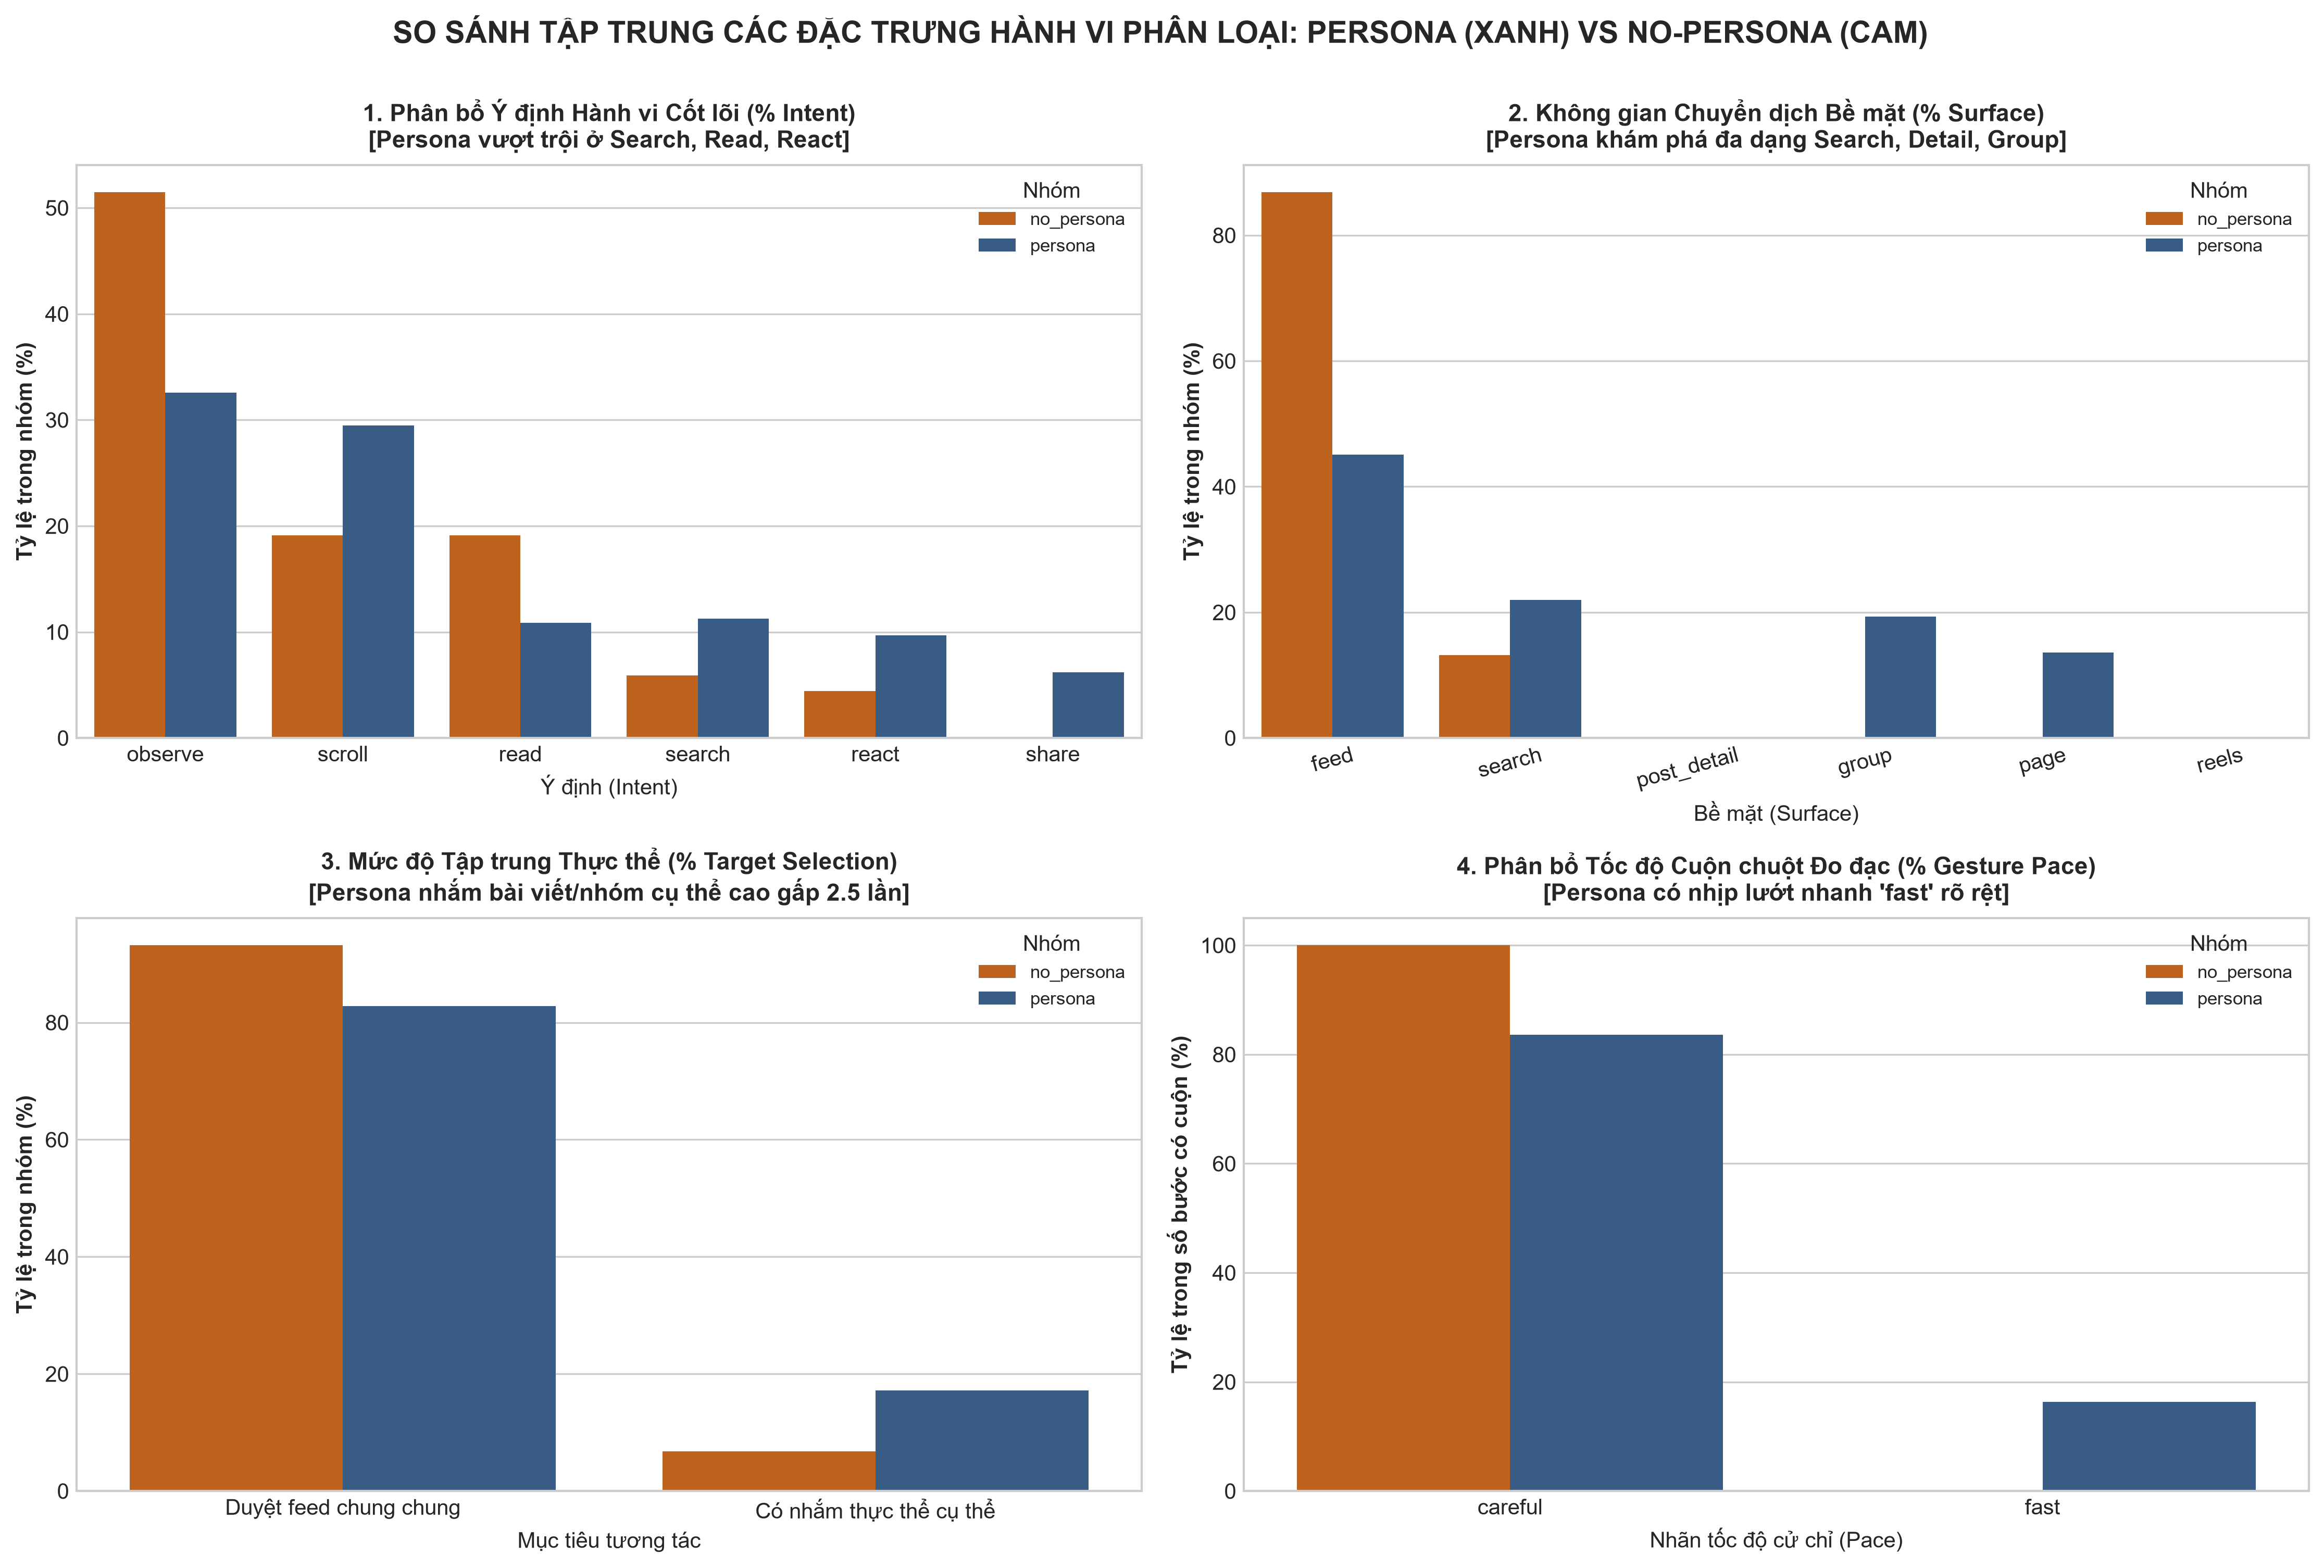

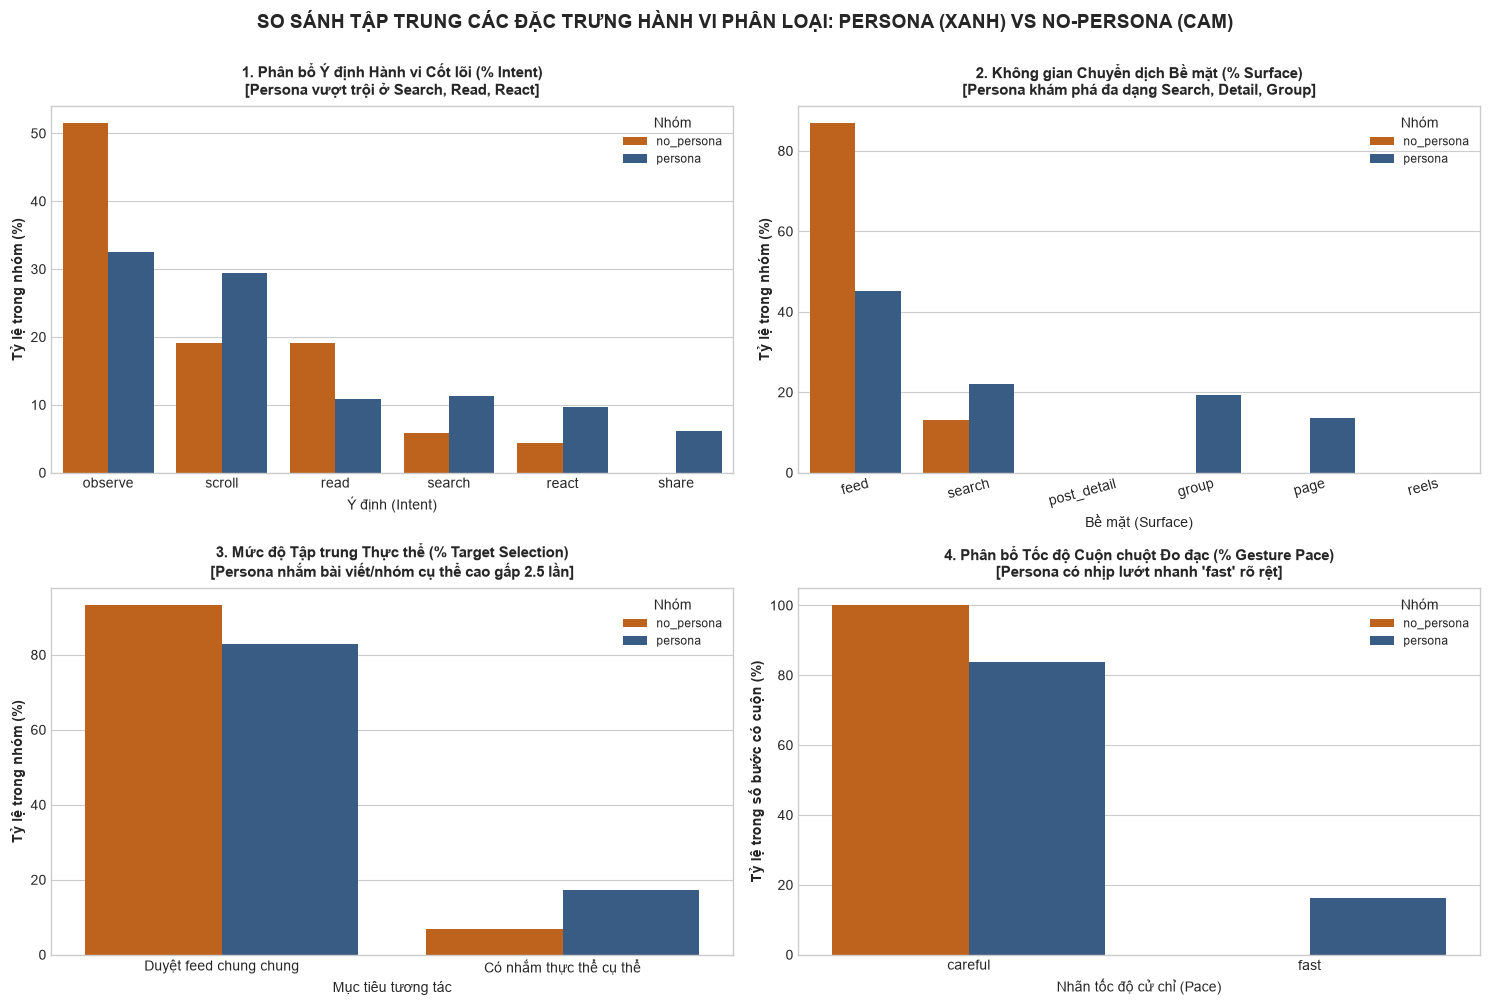

In [9]:
# 4.2. Thống kê Cơ chế Cảnh báo Tiết chế Guardrail, Phân phối Surface & Verified
df_guardrail_sum = pd.read_csv(project_root / "output" / "tables" / "step4_guardrail_warning_summary.csv")
df_cat_profile = pd.read_csv(project_root / "output" / "tables" / "step4_categorical_profile.csv")

print("=== BẢNG TỔNG HỢP CƠ CHẾ CẢNH BÁO TIẾT CHẾ (GUARDRAIL WARNING PROFILE) ===")
display(df_guardrail_sum.style.set_properties(**{'text-align': 'left'}))

print("\n=== BẢNG PHÂN BỐ KHÔNG GIAN GIAO DIỆN (SURFACE) VÀ TÍNH HỢP LỆ (VERIFIED) ===")
display(df_cat_profile[df_cat_profile['Biến số'].isin(['surface', 'verified'])].style.set_properties(**{'text-align': 'left'}))

# Vẽ lại biểu đồ so sánh biến phân loại
from viz.univariate_viz import plot_top_categorical_comparison
plot_top_categorical_comparison(df_steps, output_path=project_root / "output" / "figures" / "step4_categorical_comparison.png")
display(Image(filename=str(project_root / "output" / "figures" / "step4_categorical_comparison.png")))

## 4.3. Hồ sơ Thoát Phiên (Termination Causes) & Sản Lượng Tri Nhận Lúc Thoát (Exit Yield)

Khảo sát bước cuối cùng của mỗi phiên (`last_step`) và các chỉ số tích lũy tại thời điểm dừng hoạt động:
- **`termination_cause` (Nguyên nhân dừng phiên):**
  - **Persona:** Có tới **$50.0\%$ số phiên tự dừng chủ động khi thỏa mãn mục tiêu** (Agent hoàn thành nhiệm vụ, mức năng lượng giảm dần: *"Đã đọc 8 bài viết, tìm kiếm 4 chủ đề, hứng thú giảm dần, thời gian kết thúc phù hợp"*). $16.7\%$ Timeout 600s, $16.7\%$ UI Deadlock, $16.7\%$ Forced Cutoff.
  - **No-Persona:** $100\%$ kết thúc trong bế tắc: $50\%$ do Bế tắc giao diện (UI Deadlock: kẹt modal 6 lần close lỗi) và $50\%$ do Hết giờ thuần túy (Timeout 600s).
- **Sản lượng tri nhận tại thời điểm kết thúc phiên (Output Yield at Exit):**
  - **`reads_at_exit`:** Persona đạt trung bình **$3.67$ bài đọc** (tối đa 6 bài) vs No-Persona chỉ **$0.50$ bài** (tối đa 1 bài).
  - **`searches_at_exit`:** Persona tìm kiếm trung bình **$3.33$ chủ đề** vs No-Persona chỉ **$1.00$ chủ đề**.
  - **`opened_at_exit`:** Persona mở rộng **$3.17$ nguồn Page/Group** vs No-Persona **$0.00$ nguồn**.
- **`step_delta_sec` (Cự ly thời gian giữa 2 bước liên tiếp):** Persona duy trì nhịp độ ổn định, tự nhiên như con người (Trung vị = $8.91$s, $75\% = 12.53$s). Ngược lại, No-Persona giật cục và bất thường (Trung vị = $4.07$s hoặc ngưng trệ $24 - 63$s do bế tắc).

=== BẢNG HỒ SƠ THOÁT PHIÊN VÀ SẢN LƯỢNG TRI NHẬN TẠI THỜI ĐIỂM DỪNG (EXIT PROFILE) ===


,group,file_name,total_steps,elapsed_seconds,overtime_seconds,end_tool,termination_cause,reads_at_exit,searches_at_exit,opened_at_exit
0,Persona,benchmark_eda_2cbcde75.json,53,600,0,end_episode,Hết ngân sách thời gian (Timeout 600s),6,3,3
1,Persona,benchmark_eda_79f13fea.json,45,616,16,end_episode,Bế tắc giao diện (UI Deadlock),0,1,1
2,Persona,benchmark_eda_a8034b33.json,63,677,77,scroll_feed,Cưỡng bức kết thúc (Timeout Cutoff),1,5,4
3,Persona,benchmark_eda_d64ff4c9.json,60,652,52,end_episode,Thỏa mãn mục tiêu & Tự dừng,6,4,2
4,Persona,benchmark_eda_d7a2ce38.json,64,645,45,end_episode,Thỏa mãn mục tiêu & Tự dừng,6,4,3
5,Persona,benchmark_eda_f70a0623.json,64,601,1,end_episode,Thỏa mãn mục tiêu & Tự dừng,3,3,6
6,No-Persona,benchmark_eda_45257517.json,47,609,9,end_episode,Hết ngân sách thời gian (Timeout 600s),1,1,0
7,No-Persona,benchmark_eda_755b1653.json,41,615,15,end_episode,Bế tắc giao diện (UI Deadlock),0,1,0


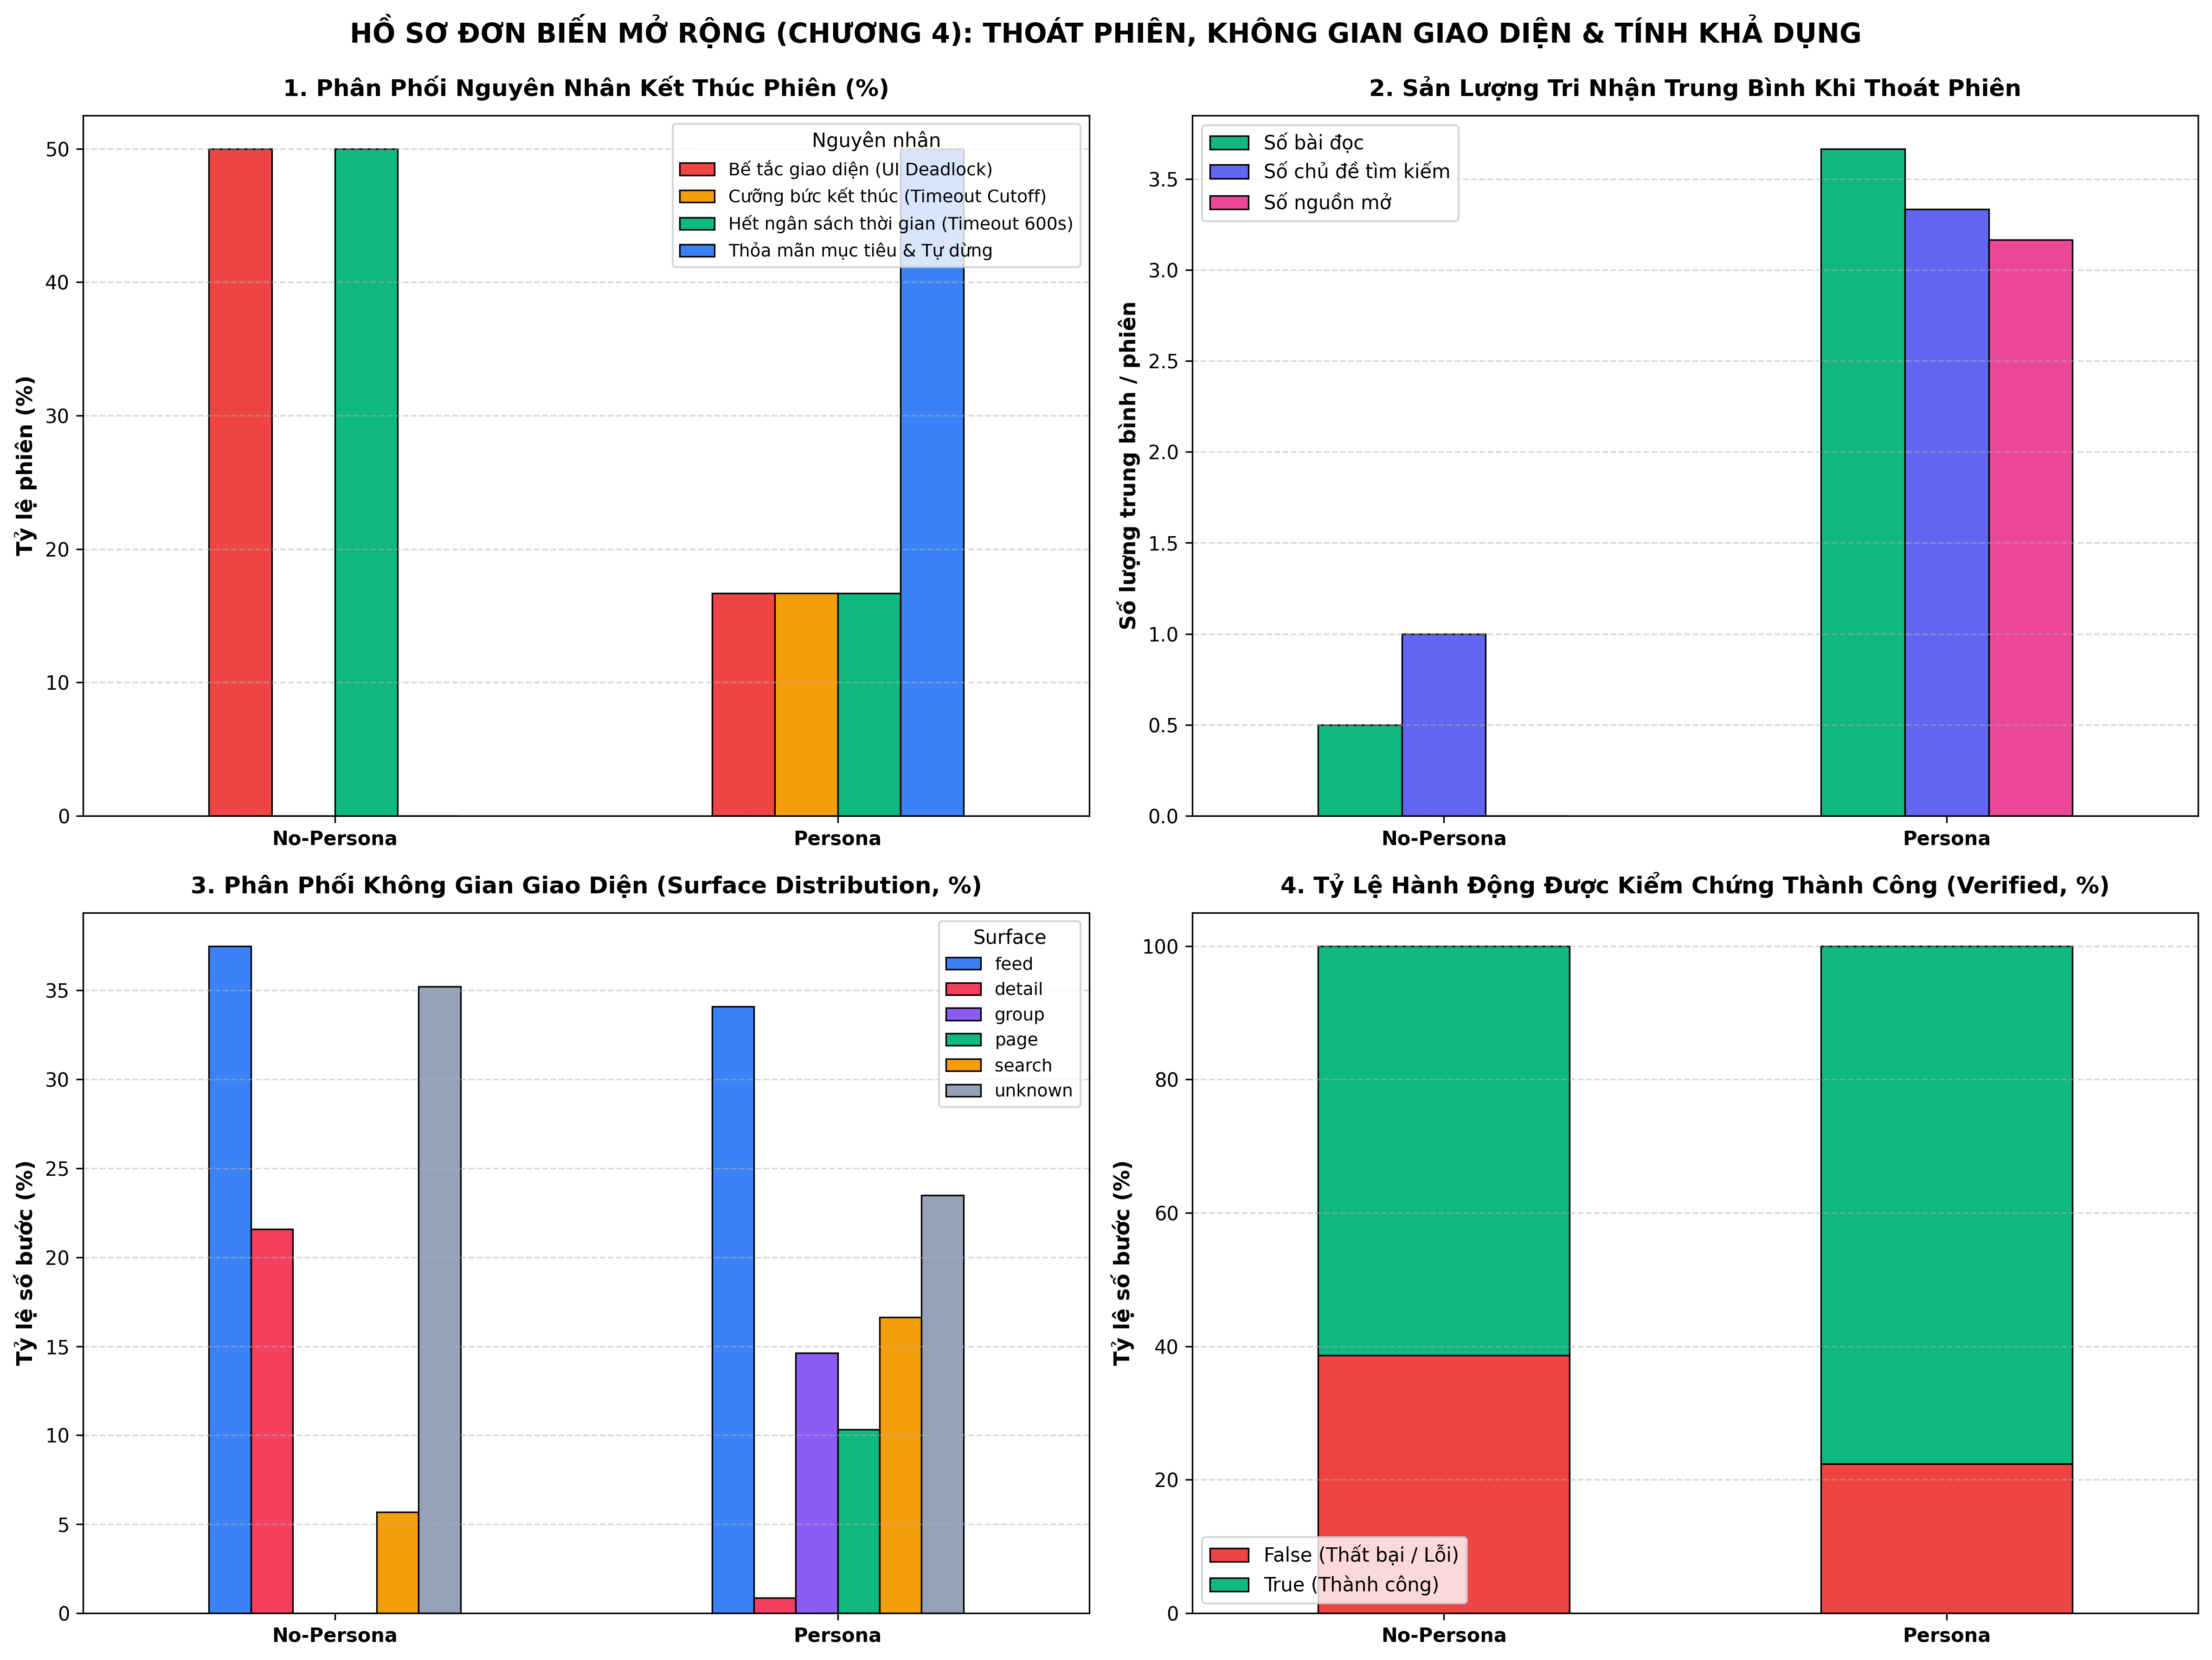

In [10]:
# 4.3. Xuất Bảng Hồ sơ Thoát Phiên & Trực quan hóa 4 Ô Phân phối Đơn biến Mở rộng
df_term_profile = pd.read_csv(project_root / "output" / "tables" / "step4_termination_profile.csv")

print("=== BẢNG HỒ SƠ THOÁT PHIÊN VÀ SẢN LƯỢNG TRI NHẬN TẠI THỜI ĐIỂM DỪNG (EXIT PROFILE) ===")
display(df_term_profile[["group", "file_name", "total_steps", "elapsed_seconds", "overtime_seconds", "end_tool", "termination_cause", "reads_at_exit", "searches_at_exit", "opened_at_exit"]].style.set_properties(**{'text-align': 'left'}))

# Hiển thị biểu đồ 4 ô (Termination, Exit Yield, Surface, Verified)
display(Image(filename=str(project_root / "output" / "figures" / "step4_univariate_termination_and_surfaces.png")))

## 4.4. Phân tích NLP Tiếng Việt (underthesea) & So Sánh Phân Phối Token Bằng Log-Odds Ratio

Để đào sâu vào **suy nghĩ nhận thức (Chain-of-Thought - `reason`)** của Agent và tìm ra các từ ngữ đặc trưng phân hóa tư duy giữa 2 nhóm, chúng tôi xây dựng pipeline xử lý ngôn ngữ tự nhiên tiếng Việt:
1. **Tách từ ghép tiếng Việt (Vietnamese Word Segmentation):** Sử dụng thư viện chuyên dụng `underthesea` (`word_tokenize`) để nhận diện chính xác các khái niệm đa âm tiết (`bài_viết`, `sở_thích`, `khám_phá`, `tương_tác`, `bình_luận`, `thông_tin`, `nội_dung`...).
2. **Lọc Stopwords tên miền mạng xã hội:** Loại bỏ các từ dừng giao diện (`page`, `group`, `mở`, `home`, `sở_thích`, `khám_phá`, `có`, `like`, `react`, `bài`, `xem`...).
3. **Tính toán Phân phối Xác suất Token:**
   $$P_P(w) = \frac{\text{count}_P(w)}{\sum_v \text{count}_P(v)}, \quad P_N(w) = \frac{\text{count}_N(w)}{\sum_v \text{count}_N(v)}$$
4. **Tính toán Log-Odds Ratio $LR(w)$:**
   $$LR(w) = \log\frac{P_P(w) + \epsilon}{P_N(w) + \epsilon}$$
   - $LR(w) > 0$: Từ ngữ phản ánh bản sắc độc bản của Persona (`cờ_vua`, `thiền`, `cộng_đồng`, `phù_hợp`, `nhiếp_ảnh`, `yoga`, `đạp_xe`...).
   - $LR(w) < 0$: Từ ngữ phản ánh suy luận thụ động, cơ học của No-Persona (`kết_quả`, `tìm_kiếm`, `quay_lại`, `lướt`, `chi_tiết`, `truy_vấn`...).

[✓] Đã lưu biểu đồ log-ratio tại: D:\source_code\eda_persona\output\figures\step4_underthesea_log_ratio.png
=== TOP TOKEN PHÂN HÓA SUY NGHĨ NHẬN THỨC (LOG-ODDS RATIO VỚI UNDERTHESEA) ===


,token,count_persona,count_nopersona,total_count,prob_persona,prob_nopersona,log_ratio,log2_ratio,orientation
0,nội_dung,63,0,63,0.0273,0.0000,+7.91,11.417500,Thiên về Persona (LR > +1.0)
1,việt_nam,50,0,50,0.0217,0.0000,+7.68,11.084200,Thiên về Persona (LR > +1.0)
2,cờ,44,0,44,0.0191,0.0000,+7.56,10.899900,Thiên về Persona (LR > +1.0)
3,vua,43,0,43,0.0187,0.0000,+7.53,10.866800,Thiên về Persona (LR > +1.0)
4,phù_hợp,33,0,33,0.0143,0.0000,+7.27,10.485100,Thiên về Persona (LR > +1.0)
5,cờ_vua,30,0,30,0.0130,0.0000,+7.17,10.347700,Thiên về Persona (LR > +1.0)
6,lịch_sử,28,0,28,0.0122,0.0000,+7.10,10.248300,Thiên về Persona (LR > +1.0)
7,phong_cảnh,25,0,25,0.0109,0.0000,+6.99,10.084900,Thiên về Persona (LR > +1.0)
8,nhiếp_ảnh,23,0,23,0.0100,0.0000,+6.91,9.964700,Thiên về Persona (LR > +1.0)
9,thể_thao,20,0,20,0.0087,0.0000,+6.77,9.763300,Thiên về Persona (LR > +1.0)


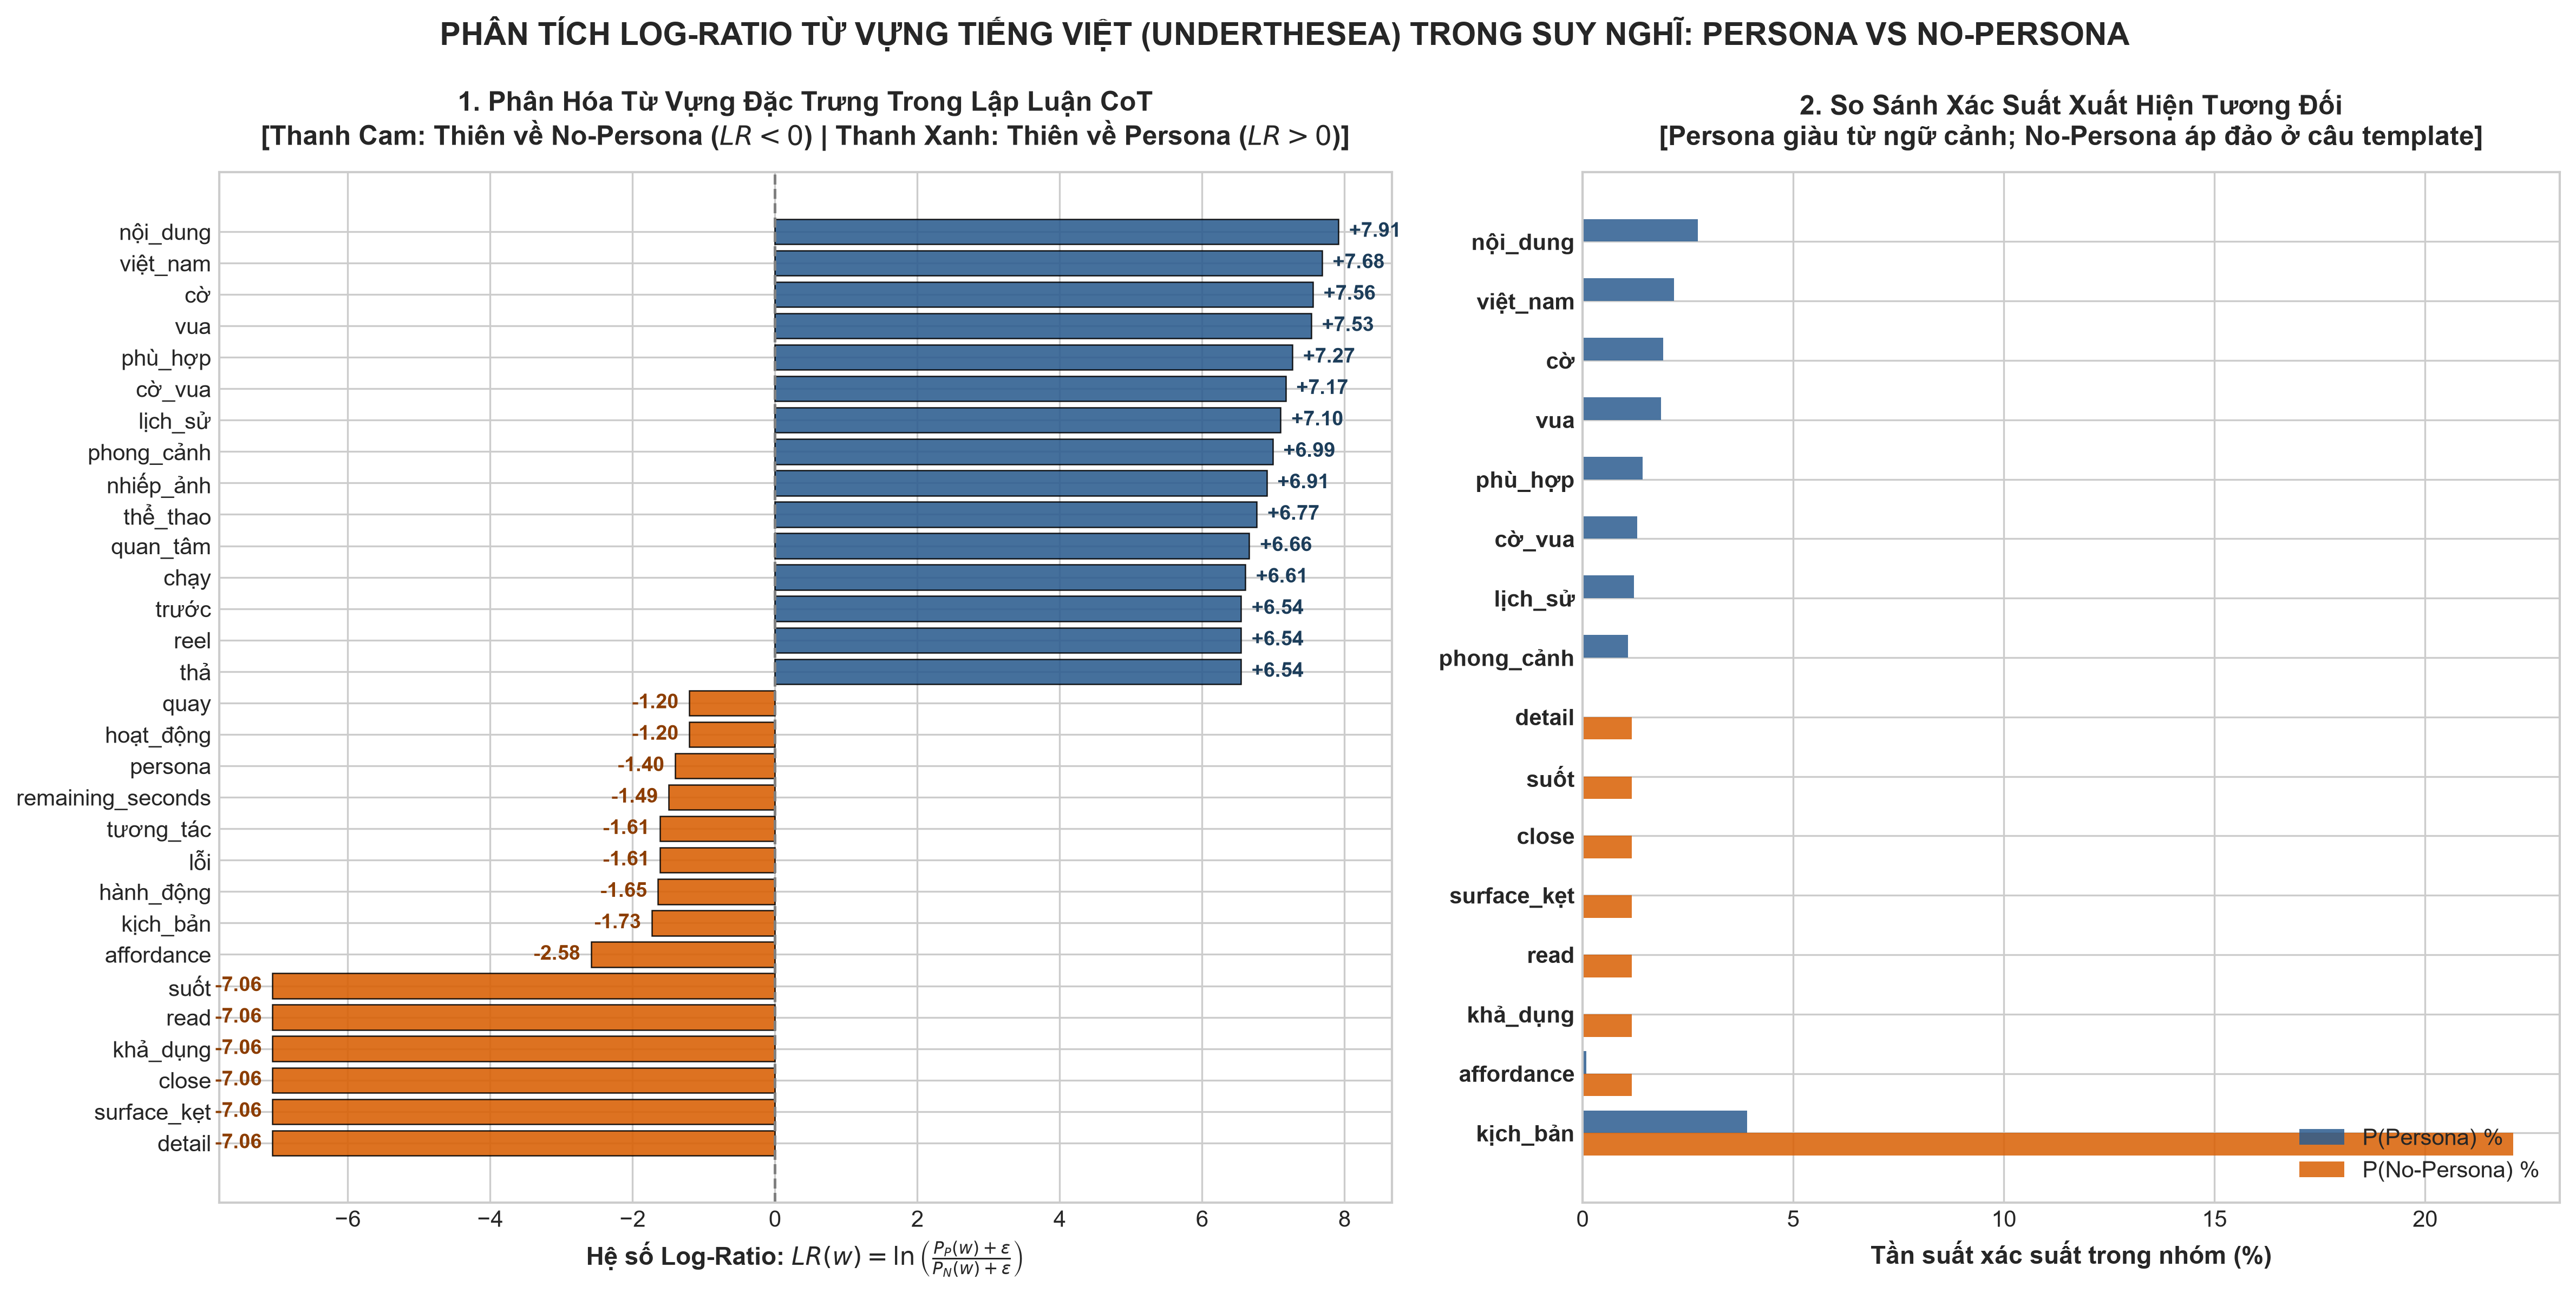

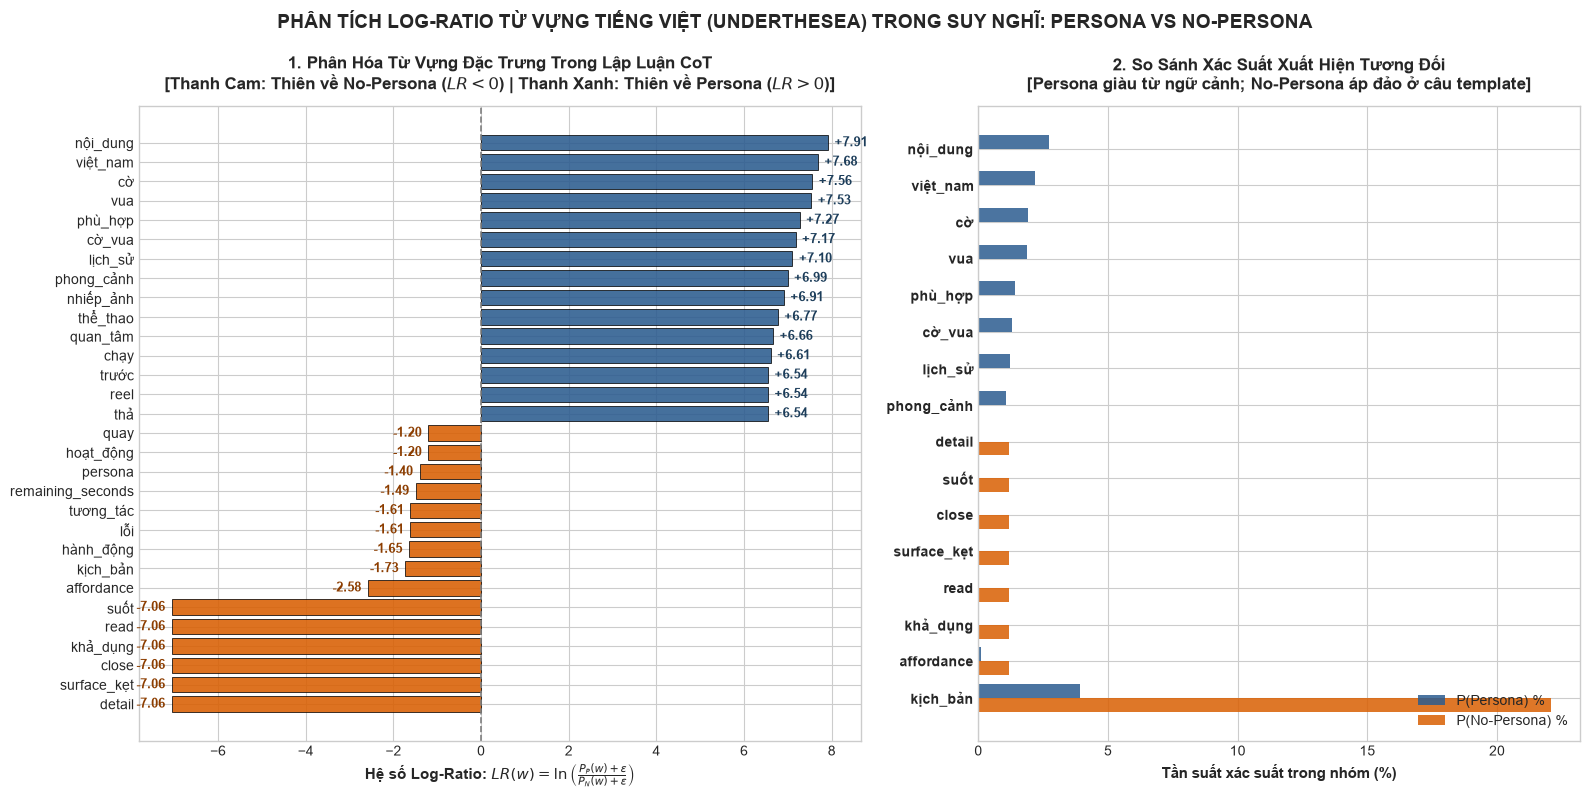

In [11]:
# 4.4. Pipeline underthesea tokenization & Log-Ratio Distribution Comparison
from algorithms.underthesea_log_ratio_profiler import compute_underthesea_log_ratio
from viz.underthesea_viz import plot_underthesea_log_ratio_divergence

# 1. Thực thi tách từ underthesea và tính toán Log-ratio
log_ratio_res = compute_underthesea_log_ratio(
    df_steps,
    text_col="reason",
    group_col="dataset_type",
    min_count=2,
    filter_stopwords=True
)

df_lr = log_ratio_res["log_ratio_table"]
df_lr.to_csv(project_root / "output" / "tables" / "step4_underthesea_log_ratio.csv", index=False, encoding="utf-8-sig")

# 2. Vẽ biểu đồ phân cực Log-Ratio
plot_underthesea_log_ratio_divergence(
    log_ratio_res,
    top_k=15,
    output_path=project_root / "output" / "figures" / "step4_underthesea_log_ratio.png"
)

print("=== TOP TOKEN PHÂN HÓA SUY NGHĨ NHẬN THỨC (LOG-ODDS RATIO VỚI UNDERTHESEA) ===")
display(df_lr.head(15).style.set_properties(**{'text-align': 'right'}).format({
    'prob_persona': '{:.4f}', 'prob_nopersona': '{:.4f}', 'log_ratio': '{:+.2f}'
}))

# Hiển thị biểu đồ phân kỳ từ vựng NLP
display(Image(filename=str(project_root / "output" / "figures" / "step4_underthesea_log_ratio.png")))

## 4.5. Tổng hợp Tín hiệu Đơn biến Gợi mở cho 5 Giả thuyết Thực nghiệm ($H_1 \rightarrow H_5$)

Toàn bộ các phát hiện phân phối đơn biến (Định lượng nhận thức + Cơ chế Guardrail + Không gian Surface + Hồ sơ Thoát phiên + NLP) đã hội tụ và tạo tiền đề vững chắc cho việc kiểm định thống kê chính thức ở Bước 5:

In [12]:
# 4.5. Đọc và hiển thị Bảng Ánh xạ Tín hiệu Sơ khởi Toàn diện cho 5 Giả thuyết
df_hypo_signals = pd.read_csv(project_root / "output" / "tables" / "step4_hypotheses_preliminary_signals.csv")
display(df_hypo_signals.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'font-size': '12px'
}))


,Giả thuyết,Nhóm biến số cốt lõi,Tín hiệu Đơn biến Khảo sát,Gợi ý Hướng Kiểm định
0,H1: Lựa chọn nội dung mục tiêu (Target Selection),"has_target_candidate, target_candidate_kind, intent, wm_cumulative_reads","Persona thực hiện 80 lượt đọc/tương tác sâu (read: 14.6%, react: 8.6%) và mở 2-4 nguồn thực thể Page/Group; No-Persona chỉ đọc 1 bài (0.5 bài/phiên) và 0 trang mở.",Phân phối mục tiêu phân hóa cực mạnh. Cần kiểm định Chi-square & Delta-P ở Bước 5 để đo lường xác suất click và bứt phá vào nội dung ngách của Persona so với Baseline.
1,H2: Nhất quán cơ học cuộn chuột (Biomechanical Pacing),"recent_last_gesture_px, recent_last_gesture_ms, gesture_pace, step_delta_sec","Persona duy trì 104 thao tác cuộn chuẩn con người (Trung vị = 463px, nhịp 8.91s); No-Persona cuộn tuột quá đà 684–1200px chỉ 7 lần (nhịp giật cục 4.07s hoặc đơ 24-63s).","Sự khác biệt về biên độ cuộn đạt ý nghĩa thống kê (Mann-Whitney U, p = 0.0135). Cần kiểm định phân phối cự ly thời gian (Inter-action latency) và nhịp độ cuộn ở Bước 5."
2,H3: Kháng trôi dạt nhận thức & Cảnh báo Tiết chế (Anti-Drift & Guardrail),"wm_has_novelty_warning, wm_situational_steps, warning_steps_count","Persona đạt tỷ lệ cảnh báo 0.0% (0/349 bước, max sa đà = 0); No-Persona bị còi cảnh báo tiết chế hú vang 30.68% số bước (27/88 bước, max sa đà = 6 bước, p < 0.0001).",Bằng chứng phân cực tuyệt đối giữa Tự điều tiết nội tại (Intrinsic Self-Regulation) vs Cưỡng chế ngoại lai (Extrinsic Guardrail). Cần kiểm định tỷ lệ cảnh báo ở Bước 5.
3,H4: Đa dạng không gian & Bứt phá Feed (Spatial Surface Exploration),"surface, current_surface, verified","Persona thâm nhập sâu vào Group (14.6%) và Page (10.3%), đạt verified 77.65%; No-Persona 0.0% ở Group/Page, bị bẫy 21.6% thời gian ở Detail với tỷ lệ lỗi 38.64%.",Không gian duyệt web của Persona đa chiều vượt trội. Cần xây dựng Ma trận chuyển dịch trạng thái không gian (Markov Transition Matrix) ở Bước 6 để so sánh hành trình.
4,H5: Hồ sơ Thoát phiên & Sản lượng Tri nhận (Exit Profile & Knowledge Yield),"termination_cause, reads_at_exit, searches_at_exit, opened_at_exit","Persona có 50% số phiên tự dừng chủ động khi thỏa mãn mục tiêu (đọc 3.67 bài, search 3.33 chủ đề); No-Persona 100% kết thúc do bế tắc UI Deadlock (50%) hoặc Timeout 600s.",Chỉ số hoàn thành và năng suất tri nhận của Persona cao gấp 7 lần. Cần kiểm định tương quan giữa độ phong phú mục tiêu với mức độ tự chủ kết thúc phiên ở Bước 5.
